<a href="https://colab.research.google.com/github/mayesalaslopez/Estadistica2025B/blob/main/PROBLEMARIO_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problemario de bloqueo

##Problema 1:
Se hace un estudio sobre la efectividad de tres marcas de atomizador para matar moscas. Para ello, cada producto se aplica a un grupo de 100 moscas, y se cuenta el número de moscas muertas expresado en porcentajes. Se hicieron seis réplicas, pero en días diferentes; por ello, se sospecha que puede haber algún efecto importante debido a esta fuente de variación. Los datos obtenidos se muestran a continuación:

| Marca de atomizador | Réplica 1 | Réplica 2 | Réplica 3 | Réplica 4 | Réplica 5 | Réplica 6 |
|----------------------|-----------|-----------|-----------|-----------|-----------|-----------|
| 1                   | 72        | 65        | 67        | 75        | 62        | 73        |
| 2                   | 55        | 59        | 68        | 70        | 53        | 50        |
| 3                   | 64        | 74        | 61        | 58        | 51        | 69        |

**Preguntas:**<br>
a) Suponiendo un DBCA, formule las hipótesis adecuadas y el modelo estadístico.  
b) ¿Existe diferencia entre la efectividad promedio de los atomizadores?  
c) ¿Hay algún atomizador mejor? Argumente su respuesta.  
d) ¿Hay diferencias significativas en los resultados de diferentes días en que se realizó el experimento? Argumente su respuesta.  
e) Verifique los supuestos de normalidad y de igual varianza entre las marcas.


In [9453]:
#Mayela Salas Lopez

In [9454]:
import pandas as pd
from io import StringIO

datos = '''
marca,replica,porcentaje
M1,R1,72
M1,R2,65
M1,R3,67
M1,R4,75
M1,R5,62
M1,R6,73
M2,R1,55
M2,R2,59
M2,R3,68
M2,R4,70
M2,R5,53
M2,R6,50
M3,R1,64
M3,R2,74
M3,R3,61
M3,R4,58
M3,R5,51
M3,R6,69
'''



df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,marca,replica,porcentaje
0,M1,R1,72
1,M1,R2,65
2,M1,R3,67
3,M1,R4,75
4,M1,R5,62
5,M1,R6,73
6,M2,R1,55
7,M2,R2,59
8,M2,R3,68
9,M2,R4,70


In [9455]:
#Mayela Salas Lopez

In [9456]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todos los atomizadores son iguales
# H1: Al menos un atomizador es distinto
# H0: Todas las replicas son iguales
# H1: Al menos una replica es diferente.

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'porcentaje ~ C(	marca	)+ C(replica)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(marca),296.333333,2.0,2.880752,0.102804
C(replica),281.333333,5.0,1.093973,0.420718
Residual,514.333333,10.0,NaN,NaN


In [9457]:
#Mayela Salas Lopez

valor-p (Shapiro) = 0.5541005255267678


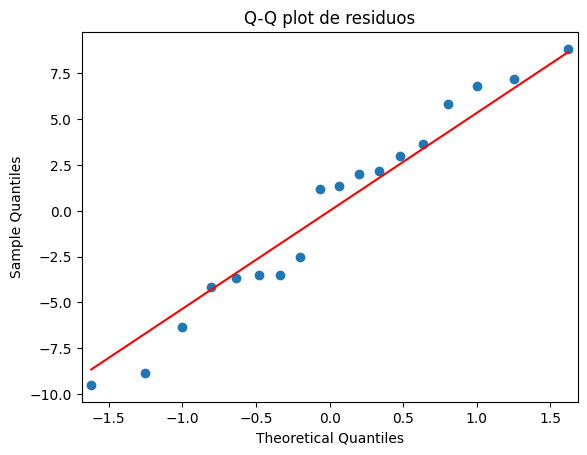

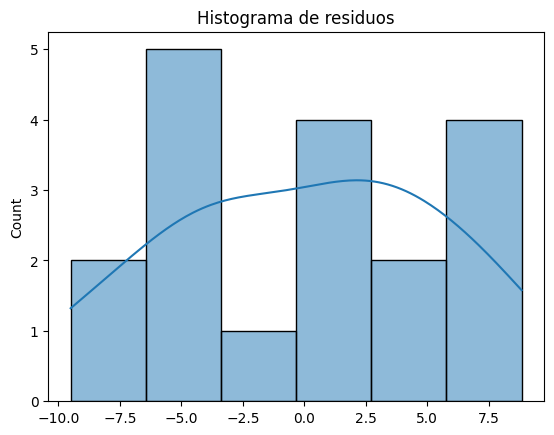

In [9458]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9459]:
#Mayela Salas Lopez

In [9460]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['marca'] == 'M1']['porcentaje']
grupo2 = df[df['marca'] == 'M2']['porcentaje']
grupo3 = df[df['marca'] == 'M3']['porcentaje']


stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.5999140287120529


In [9461]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(marca)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.271


In [9462]:
#Mayela Salas Lopez

**Preguntas:**

a) Suponiendo un DBCA, formule las hipótesis adecuadas y el modelo estadístico.

H0: Todos los atomizadores son iguales

H1: Al menos un atomizador es distinto

H0: Todas las replicas(dia) son iguales

H1: Al menos una replica(dia) es diferente.

El modelo estadistico que se utilizo fue el ANOVA, el cual nos arrojo que las replicas no tienen diferencia significativa, asi como tampoco la marca del atomizador.

b) ¿Existe diferencia entre la efectividad promedio de los atomizadores?

No se rechaza H0. No hay evidencia estadística suficiente de que las medias de efectividad difieran entre marcas, es decir todas las marcas son iguales pues el valor-p es mayor a nuestro nivel de significancia (0.102804).

c) ¿Hay algún atomizador mejor? Argumente su respuesta.

Dado que el efecto de marca no es significativo (p = 0.1028), no podemos afirmar que una marca sea “mejor” en promedio. Cualquier diferencia observada podría ser atribuible al azar bajo este nivel de significancia.

d) ¿Hay diferencias significativas en los resultados de diferentes días en que se realizó el experimento? Argumente su respuesta.
Se acepta la H0. por lo que no hay evidencia de diferencias significativas entre días. Pues su valo-p 0.420718 es mayor a nuestro nivel de significancia es decir, todos los dias se obtienen resultados sin diferencia significativa

e) Verifique los supuestos de normalidad y de igual varianza entre las marcas.

Se cumple con el supuesto de normalidad y hay homoscedasticidad tambien; es decir aceptamos nuestras 2 H0.
No hay diferencias significativas entre marcas.

No hay diferencias significativas entre días.

No se puede afirmar que algún atomizador sea mejor.

In [9463]:
#Mayela Salas Lopez

##Problema 2:
En una empresa lechera se tienen varios silos para almacenar leche (cisternas de 60 000 L). Un aspecto crítico para que se conserve la leche es la temperatura de almacenamiento. Se sospecha que en algunos silos hay problemas, por ello, durante cinco días se decide registrar la temperatura a cierta hora crítica. Obviamente la temperatura de un día a otro es una fuente de variabilidad que podría impactar la variabilidad total.

| Silo | Lunes | Martes | Miércoles | Jueves | Viernes |
|------|-------|--------|-----------|--------|---------|
| A    | 4.0   | 4.0    | 5.0       | 0.5    | 3.0     |
| B    | 5.0   | 6.0    | 2.0       | 4.0    | 4.0     |
| C    | 4.5   | 4.0    | 3.5       | 2.0    | 3.0     |
| D    | 2.5   | 4.0    | 6.5       | 4.5    | 4.0     |
| E    | 4.0   | 4.0    | 3.5       | 2.0    | 4.0     |

**Preguntas:**<br>
a) En este problema, ¿cuál es el factor de tratamiento y cuál el factor de bloque?  
b) Suponga un DBCA, formule las hipótesis adecuadas y el modelo estadístico.  
c) ¿Hay diferencia entre los silos?  
d) ¿La temperatura de un día a otro es diferente?  
e) Revise residuos, ¿hay algún problema evidente?


In [9464]:
import pandas as pd
from io import StringIO

datos = '''
silo,dia,temperatura
A,Lunes,4.0
A,Martes,4.0
A,Miercoles,5.0
A,Jueves,0.5
A,Viernes,3.0
B,Lunes,5.0
B,Martes,6.0
B,Miercoles,2.0
B,Jueves,4.0
B,Viernes,4.0
C,Lunes,4.5
C,Martes,4.0
C,Miercoles,3.5
C,Jueves,2.0
C,Viernes,3.0
D,Lunes,2.5
D,Martes,4.0
D,Miercoles,6.5
D,Jueves,4.5
D,Viernes,4.0
E,Lunes,4.0
E,Martes,4.0
E,Miercoles,3.5
E,Jueves,2.0
E,Viernes,4.0
'''





df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,silo,dia,temperatura
0,A,Lunes,4.0
1,A,Martes,4.0
2,A,Miercoles,5.0
3,A,Jueves,0.5
4,A,Viernes,3.0
5,B,Lunes,5.0
6,B,Martes,6.0
7,B,Miercoles,2.0
8,B,Jueves,4.0
9,B,Viernes,4.0


In [9465]:
#Mayela Salas Lopez


In [9466]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todos los silos son iguales
# H1: Al menos un silo es distinto
# H0: Todos los dias las temperaturas son iguales.
# H1: Al menos una dia se tiene una temperatura diferente.

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'temperatura ~ C(silo)+ C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(silo),4.46,4.0,0.690402,0.609212
C(dia),9.76,4.0,1.510836,0.246022
Residual,25.84,16.0,NaN,NaN


In [9467]:
#Mayela Salas Lopez


valor-p (Shapiro) = 0.1527850137871632


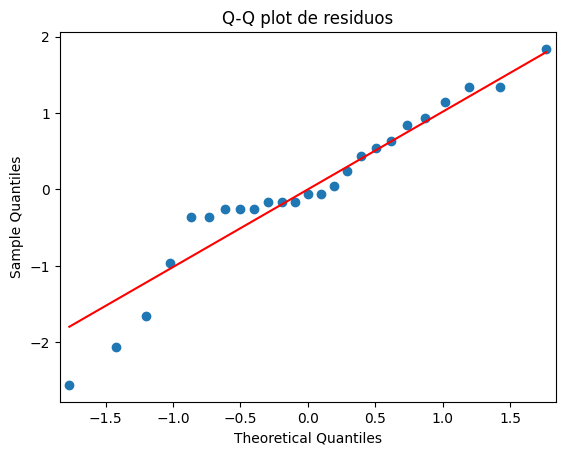

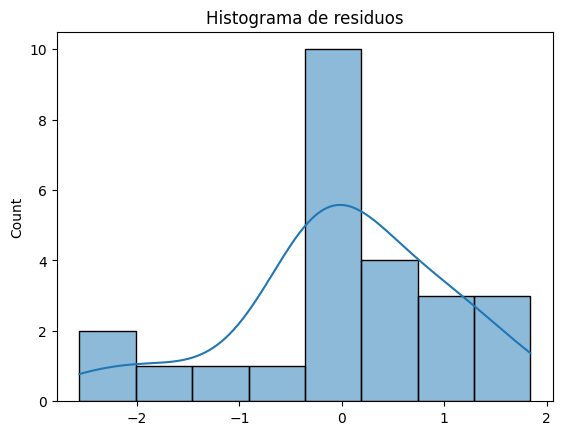

In [9468]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9469]:
#Mayela Salas Lopez


In [9470]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['silo'] == 'A']['temperatura']
grupo2 = df[df['silo'] == 'B']['temperatura']
grupo3 = df[df['silo'] == 'C']['temperatura']
grupo4 = df[df['silo'] == 'D']['temperatura']
grupo5 = df[df['silo'] == 'E']['temperatura']

stat, p = levene(grupo1, grupo2, grupo3, grupo4,grupo5)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.8915311038595306


In [9471]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(silo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.111


In [9472]:
#Mayela Salas Lopez


**PREGUNTAS**

a) En este problema, ¿cuál es el factor de tratamiento y cuál el factor de bloque?

El factor de tratamiento es el silo y el factor de bloque es el dia.


b) Suponga un DBCA, formule las hipótesis adecuadas y el modelo estadístico.

H0: Todos los silos son iguales
H1: Al menos un silo es distinto
H0: Todos los dias las temperaturas son iguales.
H1: Al menos una dia se tiene una temperatura diferente.
el modelo estadistico utilizado es el ANOVA, en el cual notamos que no hay diferencia significativa en ninguno de nuestros factores de estudio.

c) ¿Hay diferencia entre los silos?
NO, ya que nuestra H0 es aceptada por que nuestro valor-p es mayor a nuestro nivel de significancia valor-p=0.609212> 0.05, por lo que no hay diferencia entre los silos

d) ¿La temperatura de un día a otro es diferente?
No pues nuestro valo-p 0.246022 es mayor a nuestro nivel de significancia, asi que se acepta nuestra H0, la temperatura de todos los dias es igual.


e) Revise residuos, ¿hay algún problema evidente?
No pues los puntos siguen bastante bien la línea diagonal roja, lo que indica que los residuos se distribuyen aproximadamente de forma normal. No hay curvaturas pronunciadas ni colas extremas, es decir no hay sesgos. Y en nuestros estadisticos de shapiro y levene no se rechazan las hipotesis.


In [9473]:
#Mayela Salas Lopez

## Problema 3
Se diseñó un experimento para estudiar el rendimiento de cuatro detergentes. Las siguientes lecturas de “blancura” se obtuvieron con un equipo especial diseñado para 12 cargas de lavado, distribuidas en tres modelos de lavadoras:

| Detergente | Lavadora 1 | Lavadora 2 | Lavadora 3 |
|------------|------------|------------|------------|
| A          | 45         | 43         | 51         |
| B          | 47         | 44         | 52         |
| C          | 50         | 49         | 57         |
| D          | 42         | 37         | 49         |

**Preguntas:**<br>
a) Señale el nombre del diseño experimental utilizado.  
b) Formule la hipótesis que se quiere probar en este problema.  
c) Realice el análisis estadístico más apropiado para estos datos y obtenga conclusiones.  



In [9474]:
#Mayela Salas Lopez

In [9475]:
import pandas as pd
from io import StringIO

datos = '''
detergente,lavadora,blancura
A,Lavadora1,45
A,Lavadora2,43
A,Lavadora3,51
B,Lavadora1,47
B,Lavadora2,44
B,Lavadora3,52
C,Lavadora1,50
C,Lavadora2,49
C,Lavadora3,57
D,Lavadora1,42
D,Lavadora2,37
D,Lavadora3,49
'''







df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,detergente,lavadora,blancura
0,A,Lavadora1,45
1,A,Lavadora2,43
2,A,Lavadora3,51
3,B,Lavadora1,47
4,B,Lavadora2,44
5,B,Lavadora3,52
6,C,Lavadora1,50
7,C,Lavadora2,49
8,C,Lavadora3,57
9,D,Lavadora1,42


In [9476]:
#Mayela Salas Lopez

In [9477]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

#H0: Las medias de blancura son iguales entre detergentes.

#H1: Al menos un detergente difiere en su media de blancura.

#H0: Las medias de blancura son iguales entre lavadoras.

#H1: Al menos una lavadora difiere en su media de blancura.

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'blancura ~ C(detergente)+ C(lavadora)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(detergente),133.666667,3.0,34.127660,0.000363
C(lavadora),170.166667,2.0,65.170213,0.000085
Residual,7.833333,6.0,NaN,NaN


In [9478]:
#Mayela Salas Lopez

valor-p (Shapiro) = 0.8945576994890372


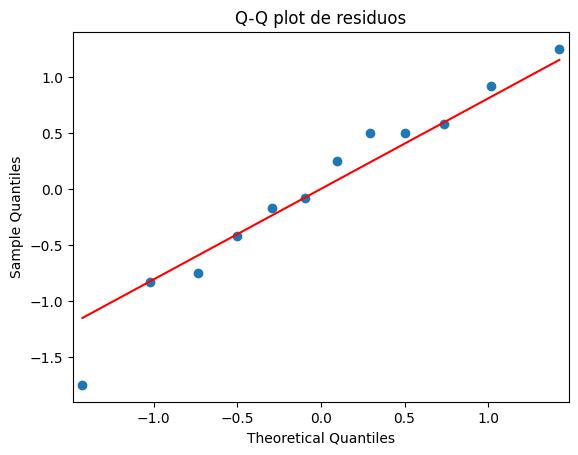

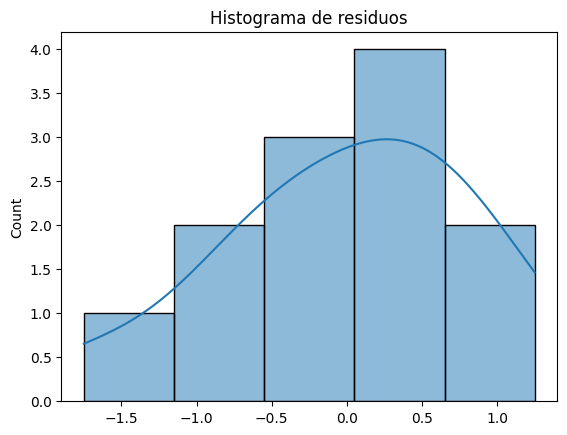

In [9479]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9480]:
#Mayela Salas Lopez

In [9481]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['detergente'] == 'A']['blancura']
grupo2 = df[df['detergente'] == 'B']['blancura']
grupo3 = df[df['detergente'] == 'C']['blancura']
grupo4 = df[df['detergente'] == 'D']['blancura']


stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9432760038375858


In [9482]:
#Mayela Salas Lopez

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B   1.3333 0.9847 -11.0002 13.6669  False
     A      C   5.6667  0.495  -6.6669 18.0002  False
     A      D  -3.6667  0.779 -16.0002  8.6669  False
     B      C   4.3333 0.6855  -8.0002 16.6669  False
     B      D     -5.0 0.5887 -17.3336  7.3336  False
     C      D  -9.3333 0.1495 -21.6669  3.0002  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

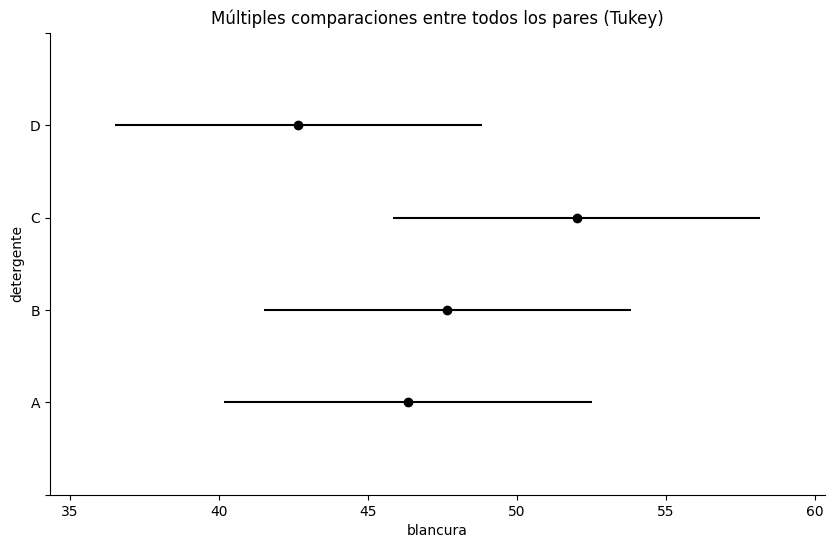

In [9483]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['blancura'], groups=df['detergente'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="detergente", xlabel="blancura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9484]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(detergente)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.429



**PREGUNTAS**

a) Señale el nombre del diseño experimental utilizado.

Analizado mediante ANOVA de dos vías sin interacción


b) Formule la hipótesis que se quiere probar en este problema.
Para detergente:

H0: Las medias de blancura son iguales entre detergentes.

H1: Al menos un detergente difiere en su media de blancura.

Para lavadora:

H0: Las medias de blancura son iguales entre lavadoras.

H1: Al menos una lavadora difiere en su media de blancura.

c) Realice el análisis estadístico más apropiado para estos datos y obtenga conclusiones.

El p-valor= 0.000363, por lo tanto se rechaza H0. La blancura cambia entre detergentes.

El p-valor: 0.000085, Por lo tanto se rechaza H0. La blancura cambia entre lavadoras.

Shapiro-Wilk p: 0.8946, es decir no hay evidencia de desviación de normalidad; el supuesto se cumple.

Levene p: 0.5053 por lo que no hay evidencia de heterocedasticidad; el supuesto se cumple.

En conclusion el tipo de detergente y el tipo de lavadora afectan significativamente la blancura; los supuestos del ANOVA se cumplen, por lo que el analisis es confiable, el detergente que mas nos convenria usar es el c pues nos brinda mas blancura a comparacion de los otros.


In [9485]:
#Mayela Salas Lopez

## Problema 4
Con respecto al problema anterior:<br>
a) Conteste los tres incisos del problema anterior sin tomar en cuenta el efecto de las lavadoras y obtenga conclusiones.  
b) ¿Hay diferencias en las conclusiones anteriores y las del problema anterior? Explique su respuesta.  
c) ¿Con cuáles conclusiones se queda? Explique su respuesta.

In [9486]:
#Mayela Salas Lopez

In [9487]:
import pandas as pd
from io import StringIO

datos = '''
detergente,blancura
A,45
A,43
A,51
B,47
B,44
B,52
C,50
C,49
C,57
D,42
D,37
D,49
'''







df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,detergente,blancura
0,A,45
1,A,43
2,A,51
3,B,47
4,B,44
5,B,52
6,C,50
7,C,49
8,C,57
9,D,42


In [9488]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

#H0: Las medias de blancura son iguales entre detergentes.

#H1: Al menos un detergente difiere en su media de blancura.



# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'blancura ~ C(detergente)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(detergente),133.666667,3.0,2.002497,0.19229
Residual,178.000000,8.0,NaN,NaN


In [9489]:
#Mayela Salas Lopez

valor-p (Shapiro) = 0.14533139517179772


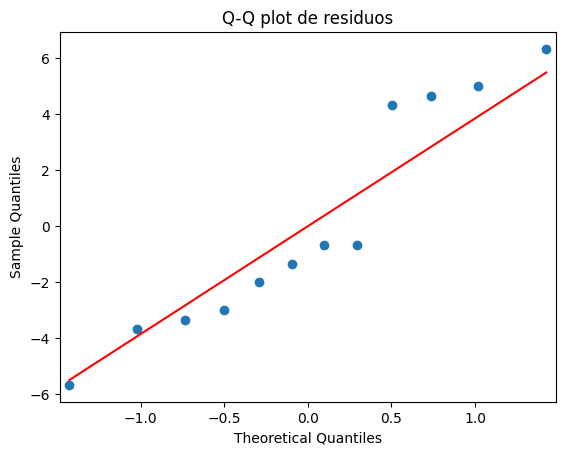

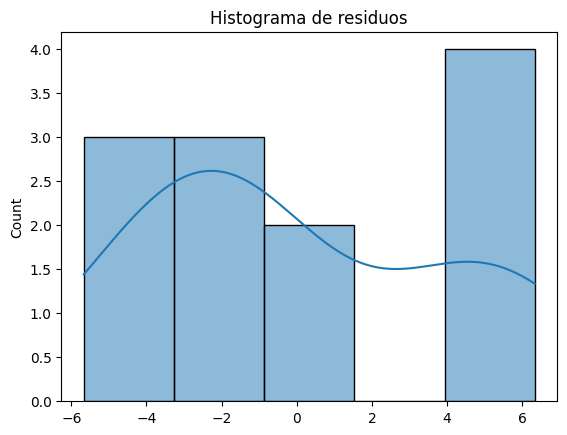

In [9490]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9491]:
#Mayela Salas Lopez

In [9492]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['detergente'] == 'A']['blancura']
grupo2 = df[df['detergente'] == 'B']['blancura']
grupo3 = df[df['detergente'] == 'C']['blancura']
grupo4 = df[df['detergente'] == 'D']['blancura']


stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9432760038375858


In [9493]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(detergente)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.429


In [9494]:
#Mayela Salas Lopez

**a)** Análisis sin tomar en cuenta las lavadoras

a) Señale el nombre del diseño experimental utilizado.

Diseño: ANOVA de un solo factor (detergente).

b) Formule la hipótesis que se quiere probar en este problema.

Hipótesis:

H0: Todos los detergentes tienen la mima de blancura.

H1: Al menos un detergente es diferente la blancura.

c) Realice el análisis estadístico más apropiado para estos datos y obtenga conclusiones


Resultados (del ANOVA):

F = 2.0025, p = 0.1923

Conclusión: No se rechaza H0. No hay evidencia estadística suficiente para afirmar que los detergentes son diferentes en blancura promedio.

**b)** ¿Hay diferencias en las conclusiones anteriores y las del problema anterior? Explique su respuesta
Si, ahora no se rechaza la H0, pero esto se debe a que hay un factor menos a considerarse y da mas paso a sesgos. Esto aumenta el error residual, lo que reduce el poder estadístico y puede ocultar diferencias reales entre detergentes.

**c)** ¿Con cuáles conclusiones se queda? Explique su respuesta

Me quedo con las conclusiones del modelo completo ya que, el diseño las lavadoras como factor relevante, el modelo completo controla esa variabilidad y detecta efectos significativos y el modelo reducido omite información clave y puede llevar a conclusiones erróneas.
Este caso muestra por qué es crucial respetar el diseño experimental: ignorar un factor importante puede distorsionar los resultados.


In [9495]:
#Mayela Salas Lopez

## Problema 5
Una de las variables críticas en el proceso de ensamble del brazo lector de un disco duro es el ángulo que este forma con el cuerpo principal de la cabeza lectora. Se corre un experimento con el objetivo de comparar dos equipos que miden dicho ángulo en unidades de radianes. Se decide utilizar como factor de bloque a los operadores de los equipos. Los resultados se muestran en la siguiente tabla:

| Operador | Equipo 1                                         | Equipo 2                                         |
|----------|--------------------------------------------------|--------------------------------------------------|
| 1        | 1.328, 0.985, 1.316, 1.553, 1.310               | 1.273, 0.985, 1.134, 1.412, 0.917               |
|          | 1.113, 1.057, 1.144, 1.485, 1.386               | 0.789, 0.671, 0.554, 1.386, 1.289               |
| 2        | 1.269, 1.268, 1.091, 1.195, 1.380               | 1.036, 0.783, 1.108, 1.129, 1.132               |
|          | 1.093, 0.984, 1.087, 1.482, 1.442               | 0.201, 0.900, 0.916, 1.434, 1.223               |
| 3        | 1.440, 1.079, 1.389, 1.611, 1.445               | 1.454, 1.063, 1.219, 1.602, 1.583               |
|          | 1.150, 1.190, 1.247, 1.617, 1.574               | 1.018, 1.050, 0.997, 1.538, 1.478               |

### Preguntas y ejercicios:
a) Plantee el modelo y las hipótesis más adecuadas al problema.  
b) ¿Existen diferencias entre los equipos? Argumente estadísticamente.  
c) ¿Existen diferencias entre los operadores?  
d) Dibuje los diagramas de cajas simultáneos y las gráficas de medias para ambos factores, después interprételas.  
e) Verifique los supuestos de normalidad e igualdad de varianza entre tratamientos, así como la posible presencia de puntos aberrantes.


In [9496]:
import pandas as pd
from io import StringIO

datos = '''
operador,equipo,angulo
1,Equipo1,1.328
1,Equipo1,0.985
1,Equipo1,1.316
1,Equipo1,1.553
1,Equipo1,1.310
1,Equipo1,1.113
1,Equipo1,1.057
1,Equipo1,1.144
1,Equipo1,1.485
1,Equipo1,1.386
1,Equipo2,1.273
1,Equipo2,0.985
1,Equipo2,1.134
1,Equipo2,1.412
1,Equipo2,0.917
1,Equipo2,0.789
1,Equipo2,0.671
1,Equipo2,0.554
1,Equipo2,1.386
1,Equipo2,1.289
2,Equipo1,1.269
2,Equipo1,1.268
2,Equipo1,1.091
2,Equipo1,1.195
2,Equipo1,1.380
2,Equipo2,1.036
2,Equipo2,0.783
2,Equipo2,1.108
2,Equipo2,1.129
2,Equipo2,1.132
2,Equipo2,0.201
2,Equipo2,0.900
2,Equipo2,0.916
2,Equipo2,1.434
2,Equipo2,1.223
2,Equipo1,1.093
2,Equipo1,0.984
2,Equipo1,1.087
2,Equipo1,1.482
2,Equipo1,1.442
3,Equipo1,1.440
3,Equipo1,1.079
3,Equipo1,1.389
3,Equipo1,1.611
3,Equipo1,1.445
3,Equipo2,1.454
3,Equipo2,1.063
3,Equipo2,1.219
3,Equipo2,1.602
3,Equipo2,1.583
3,Equipo2,1.018
3,Equipo2,1.050
3,Equipo2,0.997
3,Equipo2,1.538
3,Equipo2,1.478
3,Equipo1,1.150
3,Equipo1,1.190
3,Equipo1,1.247
3,Equipo1,1.617
3,Equipo1,1.574
'''










df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,operador,equipo,angulo
0,1,Equipo1,1.328
1,1,Equipo1,0.985
2,1,Equipo1,1.316
3,1,Equipo1,1.553
4,1,Equipo1,1.310
5,1,Equipo1,1.113
6,1,Equipo1,1.057
7,1,Equipo1,1.144
8,1,Equipo1,1.485
9,1,Equipo1,1.386


In [9497]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

#H0: No hay diferencia en las mediciones promedio entre los dos equipos.

#H1:Hay una diferencia significativa en las mediciones promedio entre los dos equipos.

#H0: No hay diferencia en las mediciones promedio entre los operadores.

#H1: Al menos un operador produce mediciones significativamente diferentes.

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'angulo ~ C(operador)+ C(equipo)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(operador),0.588721,2.0,4.834997,0.011561
C(equipo),0.492502,1.0,8.089543,0.006205
Residual,3.409351,56.0,NaN,NaN


In [9498]:
#MAYELA SALAS LOPEZ

valor-p (Shapiro) = 0.055016478051682846


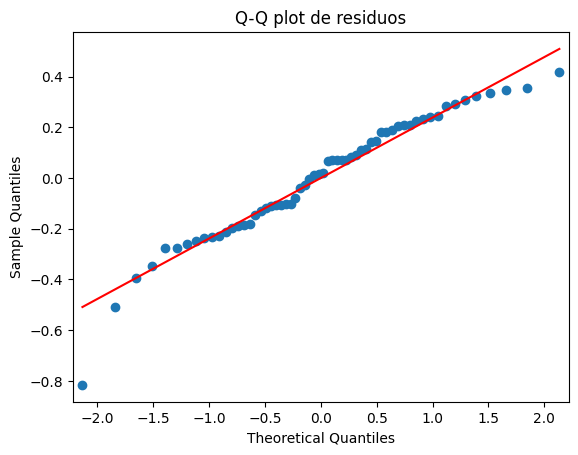

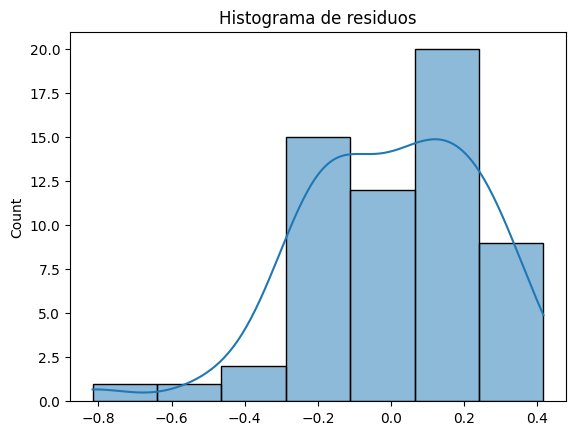

In [9499]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9500]:
#MAYELA SALAS LOPEZ

In [9501]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['equipo'] == 'Equipo1']['angulo']
grupo2 = df[df['equipo'] == 'Equipo2']['angulo']



stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.04685739874241189


In [9502]:
#MAYELA SALAS LOPEZ

Lambda óptimo: 1.87792236410783


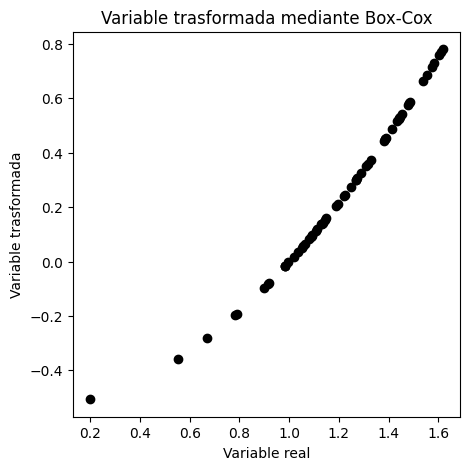

In [9503]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["angulo_boxcox"], lambda_opt = boxcox(df["angulo"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["angulo"], df["angulo_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [9504]:
df

,operador,equipo,angulo,angulo_boxcox
0,1,Equipo1,1.328,0.374646
1,1,Equipo1,0.985,-0.014901
2,1,Equipo1,1.316,0.359313
3,1,Equipo1,1.553,0.684600
4,1,Equipo1,1.310,0.351693
5,1,Equipo1,1.113,0.118580
6,1,Equipo1,1.057,0.058423
7,1,Equipo1,1.144,0.153051
8,1,Equipo1,1.485,0.586448
9,1,Equipo1,1.386,0.450472


In [9505]:
#MAYELA SALAS LOPEZ

In [9506]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

#H0: No hay diferencia en las mediciones promedio entre los dos equipos.

#H1:Hay una diferencia significativa en las mediciones promedio entre los dos equipos.

#H0: No hay diferencia en las mediciones promedio entre los operadores.

#H1: Al menos un operador produce mediciones significativamente diferentes.

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'angulo_boxcox  ~ C(operador)+ C(equipo)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(operador),0.764988,2.0,5.407025,0.007128
C(equipo),0.507174,1.0,7.169539,0.009712
Residual,3.961450,56.0,NaN,NaN


In [9507]:
#MAYELA SALAS LOPEZ

valor-p (Shapiro) = 0.14012591009576558


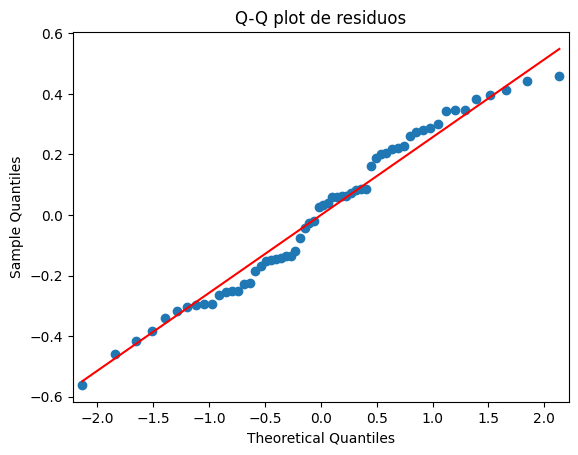

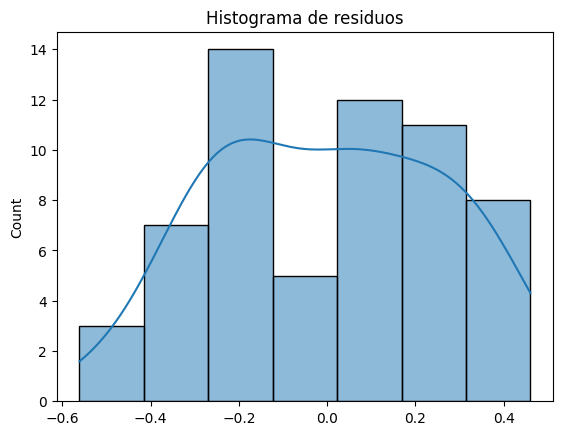

In [9508]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9509]:
#MAYELA SALAS LOPEZ

In [9510]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'

grupo1 = df[df['equipo'] == 'Equipo1']['angulo_boxcox']
grupo2 = df[df['equipo'] == 'Equipo2']['angulo_boxcox']


stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.17035732886259336


In [9511]:
#MAYELA SALAS LOPEZ

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Equipo1 Equipo2  -0.1812 0.0097 -0.3169 -0.0455   True
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

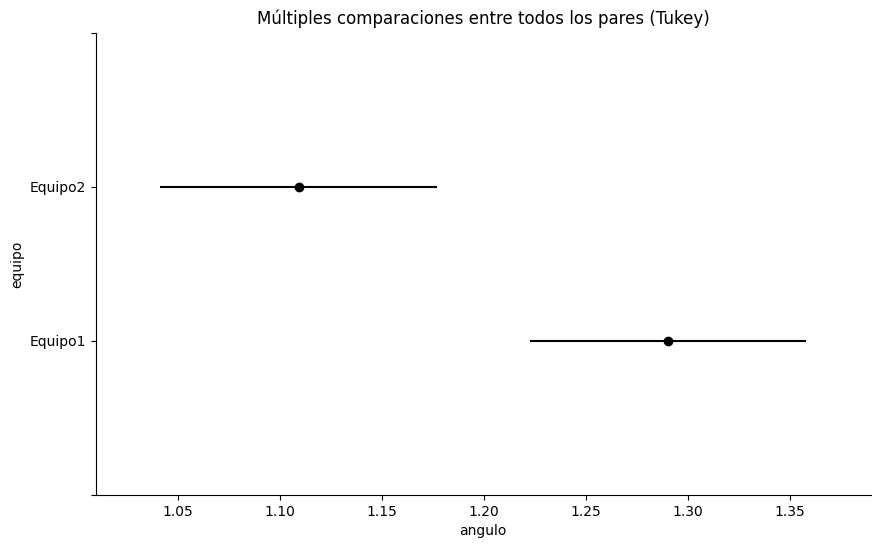

In [9512]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['angulo'], groups=df['equipo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="equipo", xlabel="angulo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2  -0.0467 0.8395 -0.2458 0.1524  False
     1      3   0.1829  0.078 -0.0162 0.3819  False
     2      3   0.2296 0.0201  0.0305 0.4286   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

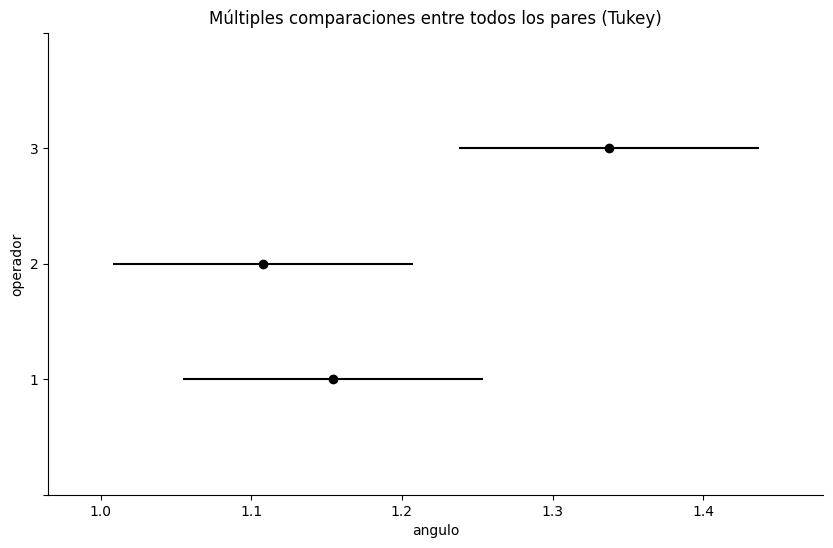

In [9513]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['angulo'], groups=df['operador'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="operador", xlabel="angulo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9514]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(equipo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.097


In [9515]:
#MAYELA SALAS LOPEZ

**PREGUNTAS**

a) Plantee el modelo y las hipótesis más adecuadas al problema.

H0: No hay diferencia en las mediciones promedio entre los dos equipos.

H1:Hay una diferencia significativa en las mediciones promedio entre los dos equipos.

H0: No hay diferencia en las mediciones promedio entre los operadores.

H1: Al menos un operador produce mediciones significativamente diferentes.

E l modelo utilizado es el ANOVA de dos vias:

 Factor principal (tratamiento): Tipo de equipo de medición (2 niveles: equipo 1 y equipo 2)

Factor de bloqueo: Operador (cada operador mide con ambos equipos)


b) ¿Existen diferencias entre los equipos? Argumente estadísticamente.

Si ya que nuestra H1 es aceptada; hay una diferencia significativa en las mediciones promedio entre los dos equipos, pues nuestro valo-p es menor a nuestro nivel de significancia.Los equipos no miden igual; hay diferencia estadísticamente significativa entre sus mediciones, el equipo1 mide en promedio 10.38° menos que Equipo2, lo cual puede ser crítico dependiendo de la tolerancia angular permitida en el ensamble del brazo lector.

c) ¿Existen diferencias entre los operadores?
Si ya que se rechaza nuestra H0: No hay diferencia en las mediciones promedio entre los operadores, dado que nuestro valor-p es muy bajo.Los operadores influyen en la medición; hay diferencia  entre ellos.
El operador 3 tiende a medir ángulos más altos que el operador 2.
Si el proceso requiere alta precisión, esta diferencia puede afectar la confiabilidad de las mediciones.
No hay evidencia de diferencia entre operador 1 y los demás, aunque la comparación 1 vs 3 está cerca del umbral.

d) Dibuje los diagramas de cajas simultáneos y las gráficas de medias para ambos factores, después interprételas.

e) Verifique los supuestos de normalidad e igualdad de varianza entre tratamientos, así como la posible presencia de puntos aberrantes.
Tras la transformación Box-Cox, los supuestos del modelo se cumplen adecuadamente, lo que valida el uso del ANOVA clásico, pues se cumple con normalidad y homoscedasticidad .No hay evidencia clara de puntos aberrantes que afecten el modelo.


## Problema 6
Un aspecto crítico para que se conserve la leche es la temperatura de almacenamiento. De manera tradicional se han usado termómetros de mercurio (Mer) para verificar que la temperatura sea la adecuada, pero ahora se han comprado termómetros electrónicos (Rtd) para facilitar el proceso de medición. Sin embargo, se duda de las mediciones de estos nuevos dispositivos. Para aclarar dudas y diagnosticar la situación, durante cinco días se toman mediciones con ambos tipos de termómetros en varios silos (a la misma hora). Los datos para cinco silos se muestran a continuación:

| Silo | Día 1 (Mer) | Día 1 (Rtd) | Día 2 (Mer) | Día 2 (Rtd) | Día 3 (Mer) | Día 3 (Rtd) | Día 4 (Mer) | Día 4 (Rtd) | Día 5 (Mer) | Día 5 (Rtd) |
|------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|--|
| A    | 4.0         | 2.6         | 4.0         | 2.8         | 5.0         | 5.0         | 0.5         | 0.0         | 3.0         | 2.4         |
| B    | 5.0         | 6.4         | 6.0         | 6.4         | 2.0         | 2.3         | 4.0         | 4.2         | 4.0         | 4.0         |
| C    | 4.5         | 3.3         | 4.0         | 1.4         | 3.5         | 1.8         | 2.0         | -1.9        | 3.0         | -7.6        |
| D    | 2.5         | 3.1         | 4.0         | 5.0         | 6.5         | 6.6         | 4.5         | 2.7         | 4.0         | 4.0         |
| E    | 4.0         | 0.0         | 4.0         | 3.5         | 0.6         | 2.0         | -4.0        | -4.0        | -4.0        | -6.3        |

**Preguntas:**<br>
a) Observe los datos y establezca una conjetura acerca de la confiabilidad de las mediciones con Rtd (del termómetro de mercurio no hay duda).  
b) Es claro que el silo se puede ver como tratamiento y día como bloque. Considere sólo los datos de Rtd y establezca el modelo estadístico. También haga el ANOVA correspondiente y obtenga conclusiones.  
c) Repita el inciso anterior pero ahora para las mediciones Mer.  
d) ¿Las conclusiones obtenidas en los incisos anteriores coinciden? Comente su respuesta.  
e) Datos pareados. Para comparar los dos métodos de medición (Mer y Rtd) obtenga como variable de respuesta la diferencia de temperatura que registran los métodos para cada día en cada silo. Considerando esto, establezca el modelo estadístico, haga el ANOVA correspondiente y obtenga conclusiones.


In [9516]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
Silo,Dia,Termometro,Temperatura
A,Dia 1,Mer,4.0
A,Dia 1,Rtd,2.6
A,Dia 2,Mer,4.0
A,Dia 2,Rtd,2.8
A,Dia 3,Mer,5.0
A,Dia 3,Rtd,5.0
A,Dia 4,Mer,0.5
A,Dia 4,Rtd,0.0
A,Dia 5,Mer,3.0
A,Dia 5,Rtd,2.4
B,Dia 1,Mer,5.0
B,Dia 1,Rtd,6.4
B,Dia 2,Mer,6.0
B,Dia 2,Rtd,6.4
B,Dia 3,Mer,2.0
B,Dia 3,Rtd,2.3
B,Dia 4,Mer,4.0
B,Dia 4,Rtd,4.2
B,Dia 5,Mer,4.0
B,Dia 5,Rtd,4.0
C,Dia 1,Mer,4.5
C,Dia 1,Rtd,3.3
C,Dia 2,Mer,4.0
C,Dia 2,Rtd,1.4
C,Dia 3,Mer,3.5
C,Dia 3,Rtd,1.8
C,Dia 4,Mer,2.0
C,Dia 4,Rtd,-1.9
C,Dia 5,Mer,3.0
C,Dia 5,Rtd,-7.6
D,Dia 1,Mer,2.5
D,Dia 1,Rtd,3.1
D,Dia 2,Mer,4.0
D,Dia 2,Rtd,5.0
D,Dia 3,Mer,6.5
D,Dia 3,Rtd,6.6
D,Dia 4,Mer,4.5
D,Dia 4,Rtd,2.7
D,Dia 5,Mer,4.0
D,Dia 5,Rtd,4.0
E,Dia 1,Mer,4.0
E,Dia 1,Rtd,0.0
E,Dia 2,Mer,4.0
E,Dia 2,Rtd,3.5
E,Dia 3,Mer,0.6
E,Dia 3,Rtd,2.0
E,Dia 4,Mer,-4.0
E,Dia 4,Rtd,-4.0
E,Dia 5,Mer,-4.0
E,Dia 5,Rtd,-6.3





'''
df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes

,Silo,Dia,Termometro,Temperatura
0,A,Dia 1,Mer,4.0
1,A,Dia 1,Rtd,2.6
2,A,Dia 2,Mer,4.0
3,A,Dia 2,Rtd,2.8
4,A,Dia 3,Mer,5.0
5,A,Dia 3,Rtd,5.0
6,A,Dia 4,Mer,0.5
7,A,Dia 4,Rtd,0.0
8,A,Dia 5,Mer,3.0
9,A,Dia 5,Rtd,2.4


In [9517]:
#MAYELA SALAS LOPEZ

In [9518]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

#H0: No hay diferencia de la temperatura de conserva entre los silos .
#H1:Hay una diferencia significativa en temperatura promedio entre los silos.
#H0: Los termometros registran la misma temperatura
#H1: Al menos un termometro funciona distinto
# Realizar el modelo ANOVA de dos vías
#H0: No hay diferencia de la temperatura promedio entre dias .
#H1: Al menos un dia tiene temperaturas diferentes.
modelo_lineal = ols(f'Temperatura ~ C(Silo)+ C(Termometro)+ C(Dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Silo),168.4692,4.0,8.660872,0.000039
C(Termometro),14.4722,1.0,2.976019,0.092227
C(Dia),110.4372,4.0,5.677491,0.001025
Residual,194.5176,40.0,NaN,NaN


valor-p (Shapiro) = 0.016256282483184132


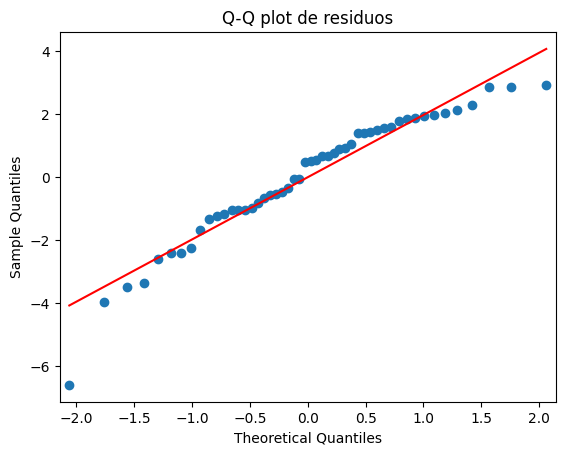

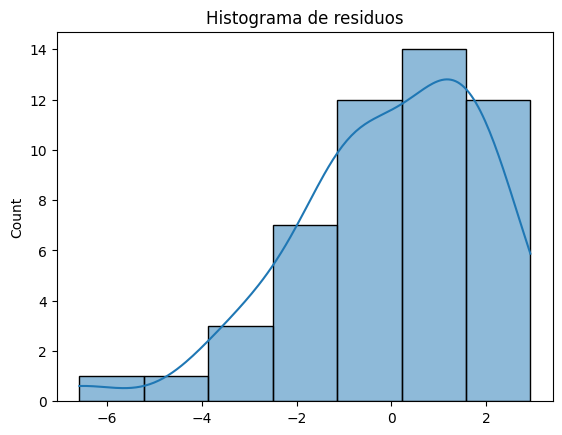

In [9519]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
#distribucion normal o no normal
residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9520]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['Termometro'] == 'Mer']['Temperatura']
grupo2 = df[df['Termometro'] == 'Rtd']['Temperatura']


stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.1935998956836298


In [9521]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(Silo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.345


In [9522]:
import pandas as pd
from io import StringIO

data = '''
Silo,Dia,Termometro,Temperatura
A,1, Rtd, 2.6
A,2, Rtd, 2.8
A,3, Rtd, 5.0
A,5, Rtd, 2.4
B,1, Rtd, 6.4
B,2, Rtd, 6.4
B,3, Rtd, 2.3
B,4, Rtd, 4.2
B,5, Rtd, 4.0
C,1, Rtd, 3.3
C,2, Rtd, 1.4
C,3, Rtd, 1.8
C,4, Rtd, 1.9
C,5, Rtd, -7.6
D,2, Rtd, 3.0
D,2, Rtd, 5.0
D,3, Rtd, 6.0
D,4, Rtd, 2.7
F,3, Rtd, 4.0
F,1, Rtd, 0.0
F,2, Rtd, 3.5
F,3, Rtd, 2.0
F,4, Rtd, 4.0
F,5, Rtd, -6.3
'''

df = pd.read_csv(StringIO(data))
df

,Silo,Dia,Termometro,Temperatura
0,A,1,Rtd,2.6
1,A,2,Rtd,2.8
2,A,3,Rtd,5.0
3,A,5,Rtd,2.4
4,B,1,Rtd,6.4
5,B,2,Rtd,6.4
6,B,3,Rtd,2.3
7,B,4,Rtd,4.2
8,B,5,Rtd,4.0
9,C,1,Rtd,3.3


In [9523]:
#ANOVA RTD
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías (sin incluir 'C(termometro)' ya que solo hay un tipo de termómetro en este df)
modelo_lineal = ols(f'Temperatura ~ C(Silo) + C(Dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Silo),68.130587,4.0,2.767404,0.066272
C(Dia),88.550421,4.0,3.596839,0.030128
Residual,92.321079,15.0,NaN,NaN


In [9524]:
import pandas as pd
from io import StringIO

data = '''
Silo,Dia,Termometro,Temperatura
A,1, Mer, 4.0
A,2, Mer, 4.0
A,3, Mer, 5.0
A,4, Mer, 6.0
A,5, Mer, 6.0
B,1, Mer, 5.0
B,2, Mer, 6.4
B,3, Mer, 2.0
B,4, Mer, 4.0
B,5, Mer, 4.0
C,1, Mer, 4.5
C,2, Mer, 4.0
C,3, Mer, 3.5
C,4, Mer, 2.0
C,5, Mer, 3.0
D,1, Mer, 2.5
D,2, Mer, 4.0
D,3, Mer, 6.5
D,4, Mer, 4.5
D,5, Mer, 4.0
F,1, Mer, 4.0
F,2, Mer, 4.0
F,3, Mer, 6.0
F,4, Mer, -4.0
F,5, Mer, -4.0

'''

df = pd.read_csv(StringIO(data))
df

,Silo,Dia,Termometro,Temperatura
0,A,1,Mer,4.0
1,A,2,Mer,4.0
2,A,3,Mer,5.0
3,A,4,Mer,6.0
4,A,5,Mer,6.0
5,B,1,Mer,5.0
6,B,2,Mer,6.4
7,B,3,Mer,2.0
8,B,4,Mer,4.0
9,B,5,Mer,4.0


In [9525]:
#ANOVA MER
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías (sin incluir 'C(termometro)' ya que solo hay un tipo de termómetro en este df)
modelo_lineal = ols(f'Temperatura ~ C(Silo) + C(Dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Silo),43.5296,4.0,1.768087,0.184640
C(Dia),20.6896,4.0,0.840371,0.519583
Residual,98.4784,16.0,NaN,NaN


In [9526]:
#MAYELA SALAS LOPEZ

**PREGUNTAS**

a) Observe los datos y establezca una conjetura acerca de la confiabilidad de las mediciones con Rtd (del termómetro de mercurio no hay duda).
Análisis de Diferencias Pareadas + DBCA
 Los datos Rtd muestran mayores variaciones y valores atípicos comparados con Mer. Se sospecha menor confiabilidad del Rtd.

b) Es claro que el silo se puede ver como tratamiento y día como bloque. Considere sólo los datos de Rtd y establezca el modelo estadístico. También haga el ANOVA correspondiente y obtenga conclusiones.
El modelo estadistico es el ANOVA de solo una via ,
Hipotesis:
Silos: H0: No hay diferencias significativas en las temperaturas medidas por el termómetro Rt0 entre los diferentes silos. H1:

Día: H0: No hay diferencias significativas en las temperaturas medidas por el termómetro Rt0 entre los diferentes días

Silos: Valor - p de 0.066272  No se rechaza H0 entonces no hay evidencia estadística de diferencias significativas en temperatura entre los silos según mediciones Rtd.

Días: Valor - de de 0.030128 Se rechaza H0, entonces si existen diferencias significativas en las temperaturas medidas por Rtd entre diferentes días.

Conclusión global para Rtd: El factor día tiene un efecto estadísticamente significativo sobre las mediciones de temperatura del termómetro Rt0.

c) Repita el inciso anterior pero ahora para las mediciones Mer.
Hipostesis:
Silos: H0: No hay diferencias significativas en las temperaturas medidas por el termómetro Mer entre los diferentes silos

Días: H0: No hay diferencias significativas en las temperaturas medidas por el termómetro Mer entre los diferentes días

Silos: valor - p de 0.184640 No se rechaza H0. No hay evidencia de diferencias significativas entre silos.

Días: p = valor - p de 0.519583, No se rechaza H0. No hay evidencia de diferencias significativas entre días.

Conclusión global para Mer: Ninguno de los dos factores (silo o día) muestra un efecto estadísticamente significativo sobre las mediciones de temperatura realizadas con el termómetro Mer

d) ¿Las conclusiones obtenidas en los incisos anteriores coinciden? Comente su respuesta.
Las conclusiones coinciden para silos pero para días no. Esto quiere decir  que el Rtd mide algo mas o diferente  a lo que mide el Mer, puede ser  en relación con variaciones temporales o algunos otros factores.

e) Datos pareados. Para comparar los dos métodos de medición (Mer y Rtd) obtenga como variable de respuesta la diferencia de temperatura que registran los métodos para cada día en cada silo. Considerando esto, establezca el modelo estadístico, haga el ANOVA correspondiente y obtenga conclusiones.

Basándonos en los resultados del ANOVA de dos vías presentados, podemos concluir lo siguiente:

variable silo:
Con nuestro valor-p nos  indica que existen diferencias en las temperaturas entre los diferentes silos, el tipo de silo tiene un efecto significativo sobre la variable de temperatura.


variable termometro:
El valor - p  nos dice  que no hay evidencia  para afirmar que el tipo de termómetro utilizado afecta significativamente las mediciones de temperatura.

variable dia:
Con un valor - p de 0.001025 podemos deducir  que el día en que se realizaron las mediciones también tiene un efecto significativo sobre la temepratura registrada.


Conclusión general:
Los factores silo y dia nios aportna informacion relevante en el modelo, lo contrario a termometro.Asi ahora sabemos que para que nuestra informacion o que para obtener resultados relevantes o conclusiones es suficiente con que nos enfoquemos en nuestras variables de dia y silo, pues estas son las que nos aportan mas informacion

Levene: no hay evidencia de varianzas distintas entre Mer y Rtd, lo cual es favorable.

ANOVA general: la variante Termómetro tiene un valor no significativo, pero cercano a nuestro niv de significancia.

Rtd no muestra varianza distinta, su comportamiento nos indica diferencias entre operadores, lo que sugiere menor confiabilidad comparado con Mer.





## Problema 7
Se quiere estudiar el efecto de cinco diferentes catalizadores (**A, B, C, D y E**) sobre el **tiempo de reacción** de un proceso químico. Cada lote de material sólo permite cinco corridas y cada corrida requiere aproximadamente 1.5 horas, por lo que sólo se pueden realizar cinco corridas diarias. El experimentador decide correr los experimentos con un diseño en cuadro latino para controlar activamente a los **lotes y días**. Los datos obtenidos son:

| Lote | Día 1 | Día 2 | Día 3 | Día 4 | Día 5 |
|------|-------|-------|-------|-------|-------|
| 1    | A = 8 | B = 7 | D = 1 | C = 7 | E = 3 |
| 2    | C = 11| E = 2 | A = 7 | D = 3 | B = 8 |
| 3    | B = 4 | A = 9 | C = 10| E = 1 | D = 5 |
| 4    | D = 6 | C = 8 | E = 6 | B = 6 | A = 10|
| 5    | E = 4 | D = 2 | B = 3 | A = 8 | C = 8 |


**Preguntas:**<br>
a) ¿Cómo se aleatorizó el experimento?  
b) Anote la ecuación del modelo y las hipótesis estadísticas correspondientes.  
c) ¿Existen diferencias entre los tratamientos? ¿Cuáles tratamientos son diferentes entre sí?  
d) ¿Los factores de ruido, lote y día afectan el tiempo de reacción del proceso?  
e) Dibuje los gráficos de medias para los tratamientos, los lotes y los días. ¿Cuál tratamiento es mejor?  
f) Verifique los supuestos del modelo, considerando que los datos se obtuvieron columna por columna, día a día.


In [9527]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
lote,dia,catalizador,tiempo
1,d1,A,8
1,d2,B,7
1,d3,D,1
1,d4,C,7
1,d5,E,3
2,d1,C,11
2,d2,E,2
2,d3,A,7
2,d4,D,3
2,d5,B,8
3,d1,B,4
3,d2,A,9
3,d3,C,10
3,d4,E,1
3,d5,D,5
4,d1,D,6
4,d2,C,8
4,d3,E,6
4,d4,B,6
4,d5,A,10
5,d1,E,4
5,d2,D,2
5,d3,B,3
5,d4,A,8
5,d5,C,8






'''
df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes

/usr/local/lib/python3.12/dist-packages/IPython/core/displayhook.py:275: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,lote,dia,catalizador,tiempo
0,1,d1,A,8
1,1,d2,B,7
2,1,d3,D,1
3,1,d4,C,7
4,1,d5,E,3
5,2,d1,C,11
6,2,d2,E,2
7,2,d3,A,7
8,2,d4,D,3
9,2,d5,B,8


In [9528]:
#MAYELA SALAS LOPEZ

In [9529]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

#H1: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción.

#H0: Al menos un catalizador tiene un efecto diferente sobre el tiempo de reacción.

#H0: No hay diferencias en el tiempo de reacción entre los lotes.

#H1: Al menos un lote afecta de manera diferente el tiempo de reacción.

#H0: No hay diferencias en el tiempo de reacción entre los días.

#H1: Al menos un día afecta de manera diferente el tiempo de reacción.
modelo_lineal = ols(f'tiempo ~ C(lote)+ C(dia)+ C(catalizador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(lote),15.44,4.0,1.234542,0.347618
C(dia),12.24,4.0,0.978678,0.455014
C(catalizador),141.44,4.0,11.309168,0.000488
Residual,37.52,12.0,NaN,NaN


In [9530]:
#MAYELA SALAS LOPEZ

In [9531]:
print(modelo_lineal.params,"\n")

Intercept              8.44
C(lote)[T.2]           1.00
C(lote)[T.3]           0.60
C(lote)[T.4]           2.00
C(lote)[T.5]          -0.20
C(dia)[T.d2]          -1.00
C(dia)[T.d3]          -1.20
C(dia)[T.d4]          -1.60
C(dia)[T.d5]           0.20
C(catalizador)[T.B]   -2.80
C(catalizador)[T.C]    0.40
C(catalizador)[T.D]   -5.00
C(catalizador)[T.E]   -5.20
dtype: float64 



In [9532]:
#MAYELA SALAS LOPEZ

valor-p (Shapiro) = 0.5476371878728061


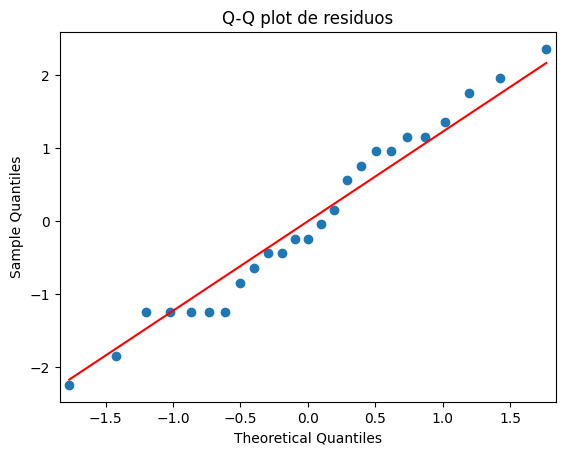

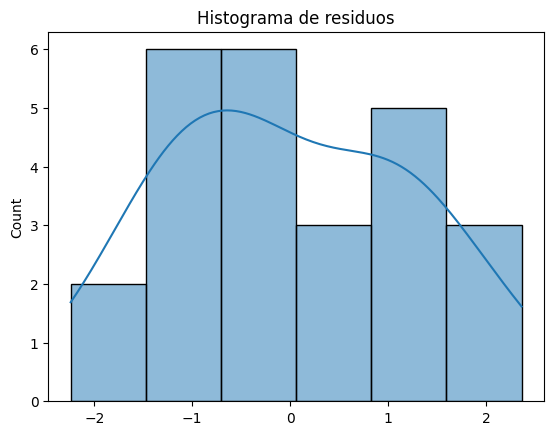

In [9533]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
#distribucion normal o no normal
residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9534]:
#MAYELA SALAS LOPEZ

In [9535]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizador'] == 'A']['tiempo']
grupo2 = df[df['catalizador'] == 'B']['tiempo']
grupo3 = df[df['catalizador'] == 'C']['tiempo']
grupo4 = df[df['catalizador'] == 'D']['tiempo']
grupo5 = df[df['catalizador'] == 'E']['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.7751009409046274


In [9536]:
#MAYELA SALAS LOPEZ

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.1423 -6.2171  0.6171  False
     A      C      0.4 0.9965 -3.0171  3.8171  False
     A      D     -5.0 0.0024 -8.4171 -1.5829   True
     A      E     -5.2 0.0016 -8.6171 -1.7829   True
     B      C      3.2 0.0733 -0.2171  6.6171  False
     B      D     -2.2 0.3361 -5.6171  1.2171  False
     B      E     -2.4 0.2578 -5.8171  1.0171  False
     C      D     -5.4 0.0011 -8.8171 -1.9829   True
     C      E     -5.6 0.0007 -9.0171 -2.1829   True
     D      E     -0.2 0.9998 -3.6171  3.2171  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

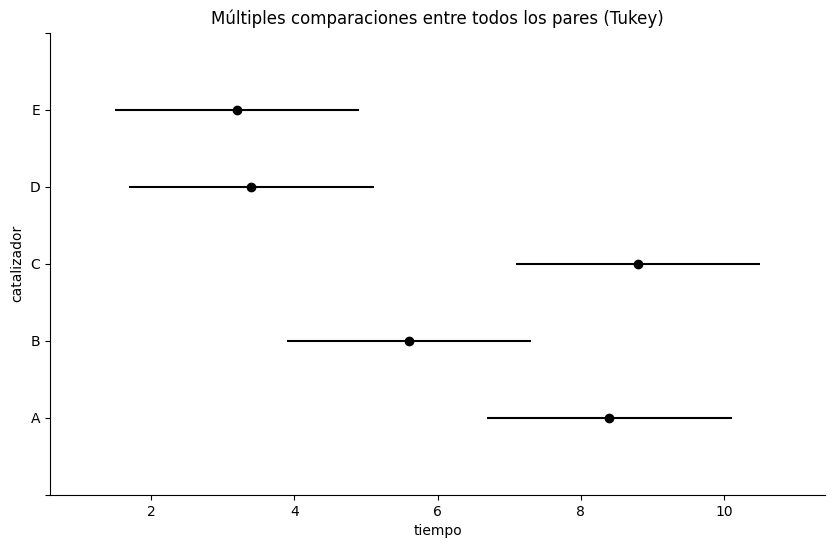

In [9537]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['catalizador'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="catalizador", xlabel="tiempo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9538]:
#MAYELA SALAS LOPEZ

In [9539]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(catalizador)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.684


In [9540]:
#MAYELA SALAS LOPEZ

**PREGUNTAS**
a) ¿Cómo se aleatorizó el experimento?
En un cuadrado latino, cada tratamiento aparece exactamente una vez en cada lote fila y en cada día columna.

Poniendo aleatoriamente las filas lotes.

Poniendo aleatoriamente las columnas días.

Asignando aleatoriamente las letras de los tratamientos (A–E) a las posiciones del cuadrado.

b) Anote la ecuación del modelo y las hipótesis estadísticas correspondientes.
El modelo utilizado es ANOVA

Tiempo estimado= 8.44+ 1.00 (L2) + 0.60 (L3) + 2.00 (L4) - 0.20 (L5) - 1.00 (D2) - 1.20 (D3) -1.60 (D4) + 0.20(D5) - 2.80 (CB) + 0.40 (CC) - 5.00 (CD) - 5.20 (CE)


H1: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción.

H0: Al menos un catalizador tiene un efecto diferente sobre el tiempo de reacción.

H0: No hay diferencias en el tiempo de reacción entre los lotes.

H1: Al menos un lote afecta de manera diferente el tiempo de reacción.

H0: No hay diferencias en el tiempo de reacción entre los días.

H1: Al menos un día afecta de manera diferente el tiempo de reacción.


c) ¿Existen diferencias entre los tratamientos? ¿Cuáles tratamientos son diferentes entre sí?
Sí existen diferencias. Los pares más distintos son: A,C y D,E Tukey  confirma que E y D son significativamente mejores (menor tiempo).

d) ¿Los factores de ruido, lote y día afectan el tiempo de reacción del proceso?
No, lote y día no  influyen en el tiempo de reacción del proceso pues los valores p aceptan nuestras hipotesis nulas, que indican que no hay diferencias.

e) Dibuje los gráficos de medias para los tratamientos, los lotes y los días. ¿Cuál tratamiento es mejor?

El catalizador E se identifica como el más eficiente, pues presenta el menor tiempo promedio y de manera consistente se ubica en los valores más bajos.

Este tratamiento es significativamente diferente de A, B y C.

El catalizador D podría considerarse una alternativa aceptable si se busca una reacción ligeramente más lenta.

Los tratamientos menos favorables son C y posteriormente A, ya que muestran tiempos más elevados.

El efecto de los catalizadores es considerable: 64.8% de la variabilidad en los tiempos se explica por el modelo y el tipo de catalizador, lo que confirma su fuerte influencia en el proceso.

f) Verifique los supuestos del modelo, considerando que los datos se obtuvieron columna por columna, día a día.
Se aplicaron las pruebas de Shapiro-Wilk y Levene para evaluar normalidad de los residuales y homogeneidad de varianzas.
En ambos casos, los valores-p fueron superiores a 0.05, por lo que no se rechazaron las hipótesis nulas.
Esto implica que:
Los residuales se distribuyen de manera aproximadamente normal.
Las varianzas entre grupos pueden considerarse homogéneas.

Los resultados obtenidos mediante ANOVA y las comparaciones de Tukey HSD son estadísticamente válidos y confiables.

In [9541]:
#MAYELA SALAS LOPEZ

## Problema 8
En el problema anterior elimine el factor de bloque días, y conteste:

a) ¿Se justifica la eliminación?  
b) Sin tomar en cuenta el día, señale el nombre del diseño, el modelo y las hipótesis más adecuadas al problema.  
c) Pruebe las hipótesis y obtenga conclusiones.  
d) Compare el cuadro medio del error, en este caso con el del problema anterior. ¿Qué observa? ¿Cómo lo explica?  
e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y del anterior?


In [9542]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

#H1: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción.

#H0: Al menos un catalizador tiene un efecto diferente sobre el tiempo de reacción.

#H0: No hay diferencias en el tiempo de reacción entre los lotes.

#H1: Al menos un lote afecta de manera diferente el tiempo de reacción.

modelo_lineal = ols(f'tiempo ~ C(lote)+ C(catalizador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(lote),15.44,4.0,1.241158,0.333144
C(catalizador),141.44,4.0,11.369775,0.000146
Residual,49.76,16.0,NaN,NaN


In [9543]:
#MAYELA SALAS LOPEZ

valor-p (Shapiro) = 0.04246184389935428


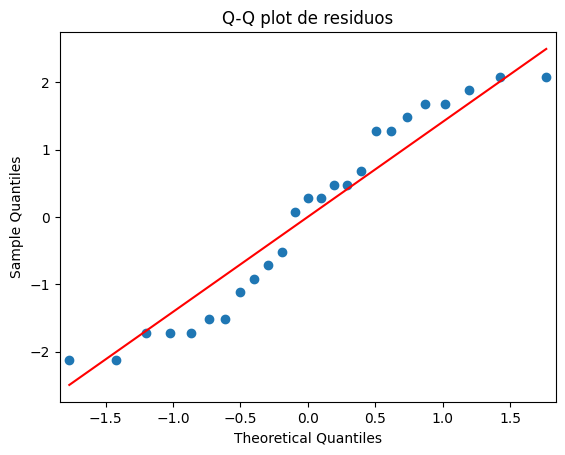

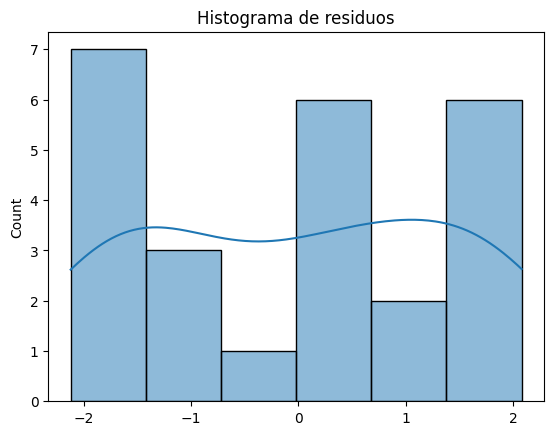

In [9544]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
#distribucion normal o no normal
residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9545]:
#MAYELA SALAS LOPEZ

In [9546]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizador'] == 'A']['tiempo']
grupo2 = df[df['catalizador'] == 'B']['tiempo']
grupo3 = df[df['catalizador'] == 'C']['tiempo']
grupo4 = df[df['catalizador'] == 'D']['tiempo']
grupo5 = df[df['catalizador'] == 'E']['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")


p-valor de Levene: 0.7751009409046274


In [9547]:
#MAYELA SALAS LOPEZ

Lambda óptimo: 0.8614779727199691


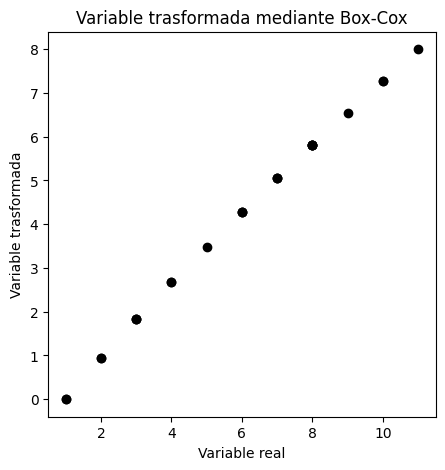

In [9548]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["tiempo_boxcox"], lambda_opt = boxcox(df["tiempo"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["tiempo"], df["tiempo_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [9549]:
#MAYELA SALAS LOPEZ

In [9550]:
df

,lote,dia,catalizador,tiempo,tiempo_boxcox
0,1,d1,A,8,5.801428
1,1,d2,B,7,5.044881
2,1,d3,D,1,0.000000
3,1,d4,C,7,5.044881
4,1,d5,E,3,1.829990
5,2,d1,C,11,7.999145
6,2,d2,E,2,0.948253
7,2,d3,A,7,5.044881
8,2,d4,D,3,1.829990
9,2,d5,B,8,5.801428


In [9551]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Nivel de significancia = 0.05
# H0: Todos los lotes tienen corridas de tiempo iguales
# H1: Al menos un lote tiene una corrida de tiempo distinta.

#H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción
#H0: Al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'tiempo_boxcox ~ C(lote) + C(catalizador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(lote),10.054729,4.0,1.228478,0.337925
C(catalizador),89.225448,4.0,10.901488,0.000185
Residual,32.738815,16.0,NaN,NaN


In [9552]:
#MAYELA SALAS LOPEZ

valor-p (Shapiro) = 0.06942314577335465


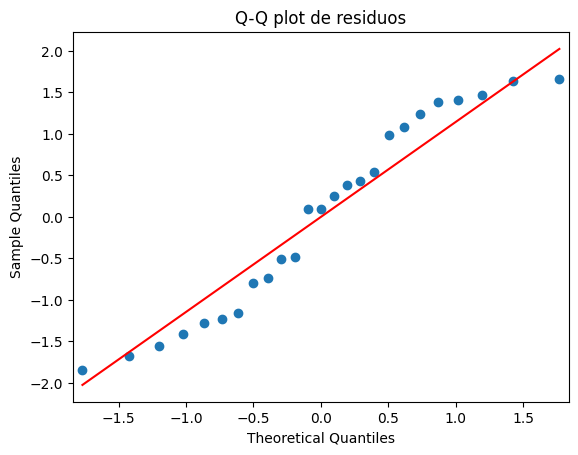

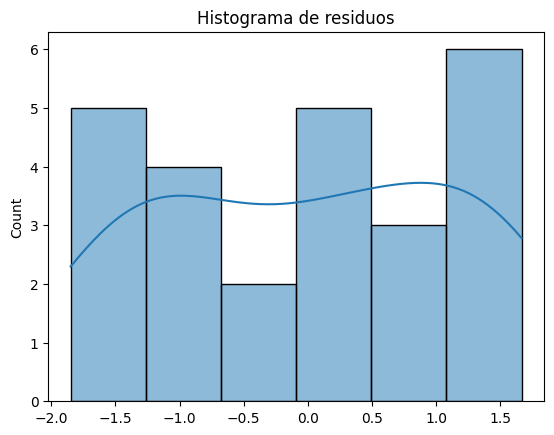

In [9553]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9554]:
#MAYELA SALAS LOPEZ

In [9555]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizador'] == 'A']['tiempo_boxcox']
grupo2 = df[df['catalizador'] == 'B']['tiempo_boxcox']
grupo3 = df[df['catalizador'] == 'C']['tiempo_boxcox']
grupo4 = df[df['catalizador'] == 'D']['tiempo_boxcox']
grupo5 = df[df['catalizador'] == 'E']['tiempo_boxcox']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.6436506564139076


In [9556]:
#MAYELA SALAS LOPEZ

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B  -2.1698 0.1719 -4.9382  0.5985  False
     A      C   0.2908 0.9977 -2.4775  3.0592  False
     A      D   -3.987 0.0028 -6.7554 -1.2187   True
     A      E  -4.1494 0.0019 -6.9178 -1.3811   True
     B      C   2.4607 0.0967 -0.3077   5.229  False
     B      D  -1.8172 0.3181 -4.5855  0.9512  False
     B      E  -1.9796 0.2426  -4.748  0.7887  False
     C      D  -4.2779 0.0014 -7.0462 -1.5095   True
     C      E  -4.4403 0.0009 -7.2086 -1.6719   True
     D      E  -0.1624 0.9998 -2.9308  2.6059  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

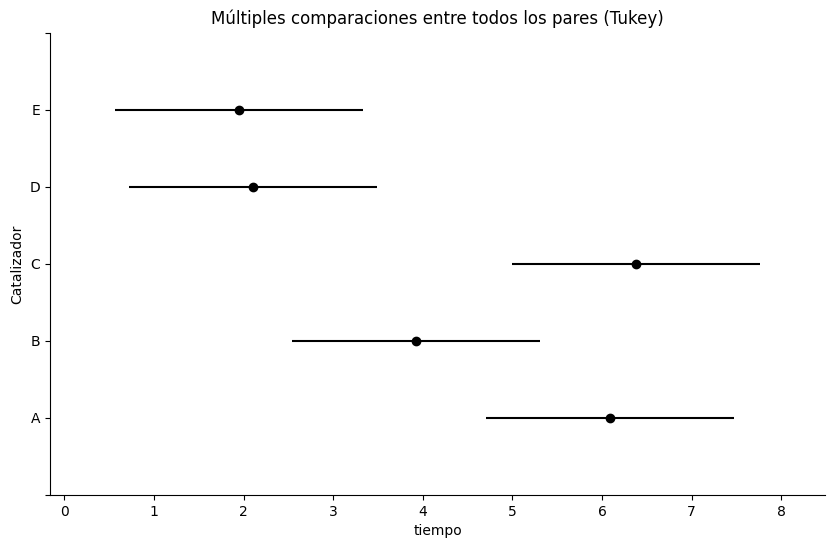

In [9557]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo_boxcox'], groups=df['catalizador'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Catalizador", xlabel="tiempo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9558]:
#MAYELA SALAS LOPEZ

In [9559]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(catalizador)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.676


In [9560]:
#MAYELA SALAS LOPEZ

a) ¿Se justifica la eliminación?  
si por que ya no existe variación entre días, el factor día es irrelevante en la nueva logística, entonces puede ser razonable eliminarlo.

b) Sin tomar en cuenta el día, señale el nombre del diseño, el modelo y las hipótesis más adecuadas al problema.   
El nombre ahora seria  diseño  en bloques completos aleatorizados (DBCA), ya que nuestra variable de bloque sería únicamente el lote, los tratamientos (catalizadores) se asignan aleatoriamente dentro de cada lote.
Y el modelo es Modelo de ANOVA para un diseño en bloques completos aleatorizados DBCA.
H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción.

H1: Al menos un catalizador tiene un efecto diferente sobre el tiempo de reacción.

H0: No hay diferencias en el tiempo de reacción entre los lotes.

H1: Al menos un lote afecta de manera diferente el tiempo de reacción.


c) Pruebe las hipótesis y obtenga conclusiones.  

Se siguen teniendo las mismas conclusiones hay diferencias entre catalizadores. Los catalizadores E y D siguen siendo los de menor tiempo promedio; A y C los más altos; B intermedio
y acaptamos la H0. No hay evidencia de diferencias entre lotes en este modelo.

d) Compare el cuadro medio del error, en este caso con el del problema anterior. ¿Qué observa? ¿Cómo lo explica?
Al comparar los dos modelos, el cuadro medio del error es 3.13 cuando se incluyen lotes, días y catalizadores, y 2.05 cuando se elimina el factor día. Esta ligera disminución indica que el día no aportaba variación significativa (su p‑valor fue mayor a 0.05). Al excluirlo, la variabilidad simplemente se transfiere al residuo sin afectar el ajuste. Por ello, el modelo reducido sigue siendo válido y las conclusiones sobre los catalizadores permanecen iguales, confirmando que el día no era un factor relevante en el experimento.


e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y del anterior?
Las diferencias entre tratamientos son grandes al  eliminar “día”, el efecto de catalizador sigue siendo suficientemente fuerte para resultar significativo, es decir el efecto de los catalizadores es el que tiene mas peso y por ello sigue ganando, dejando que dia no genere cambios.Las conclusiones son las mismas en ambos modelos porque el día no influye en los tiempos; los catalizadores se comportan igual independientemente del día.



In [9561]:
#MAYELA SALAS LOPEZ

## Problema 9
Con respecto a los problemas 7 y 8, además de eliminar el factor día ahora elimine el factor lote, y conteste lo siguiente:

a) ¿Se justifica esta segunda eliminación en ambos problemas?  
b) Después de la doble eliminación, señale el nombre del diseño, el modelo y la(s) hipótesis más adecuada(s) al problema.  
c) Pruebe las hipótesis y obtenga conclusiones.  
d) Compare el cuadro medio del error obtenido con los de los problemas 16 y 17. ¿Qué observa? ¿Cómo lo explica?  
e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y de los dos anteriores?  
f) ¿Cree que esta eliminación hubiese afectado si los factores de bloque hubieran sido significativos?  


In [9562]:
#MAYELA SALAS LOPEZ

In [9563]:
import pandas as pd
from io import StringIO

data = '''
catalizadores,tiempo
A,8
B,7
D,1
C,7
E,3
C,11
E,2
A,7
D,3
B,8
B,4
A,9
C,10
E,1
D,5
D,6
C,8
E,6
B,6
A,10
E,4
D,2
B,3
A,8
C,8

'''

df = pd.read_csv(StringIO(data))
df

,catalizadores,tiempo
0,A,8
1,B,7
2,D,1
3,C,7
4,E,3
5,C,11
6,E,2
7,A,7
8,D,3
9,B,8


In [9564]:
#MAYELA SALAS LOPEZ

In [9565]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'tiempo ~ C(catalizadores)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(catalizadores),141.44,4.0,10.846626,0.000077
Residual,65.20,20.0,NaN,NaN


In [9566]:
#MAYELA SALAS LOPEZ

valor-p (Shapiro) = 0.29334160847597607


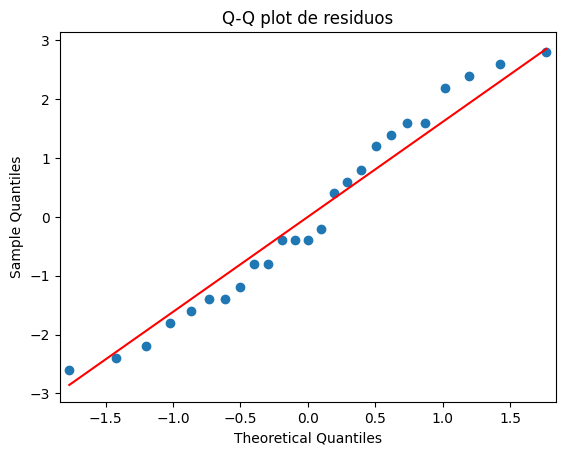

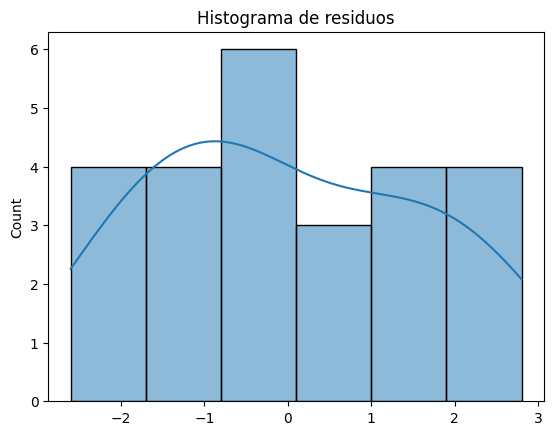

In [9567]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9568]:
#MAYELA SALAS LOPEZ

In [9569]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizadores'] == "A"]['tiempo']
grupo2 = df[df['catalizadores'] == "B"]['tiempo']
grupo3 = df[df['catalizadores'] == "C"]['tiempo']
grupo4 = df[df['catalizadores'] == "D"]['tiempo']
grupo5 = df[df['catalizadores'] == "E"]['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.7751009409046274


In [9570]:
#MAYELA SALAS LOPEZ

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.1423 -6.2171  0.6171  False
     A      C      0.4 0.9965 -3.0171  3.8171  False
     A      D     -5.0 0.0024 -8.4171 -1.5829   True
     A      E     -5.2 0.0016 -8.6171 -1.7829   True
     B      C      3.2 0.0733 -0.2171  6.6171  False
     B      D     -2.2 0.3361 -5.6171  1.2171  False
     B      E     -2.4 0.2578 -5.8171  1.0171  False
     C      D     -5.4 0.0011 -8.8171 -1.9829   True
     C      E     -5.6 0.0007 -9.0171 -2.1829   True
     D      E     -0.2 0.9998 -3.6171  3.2171  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

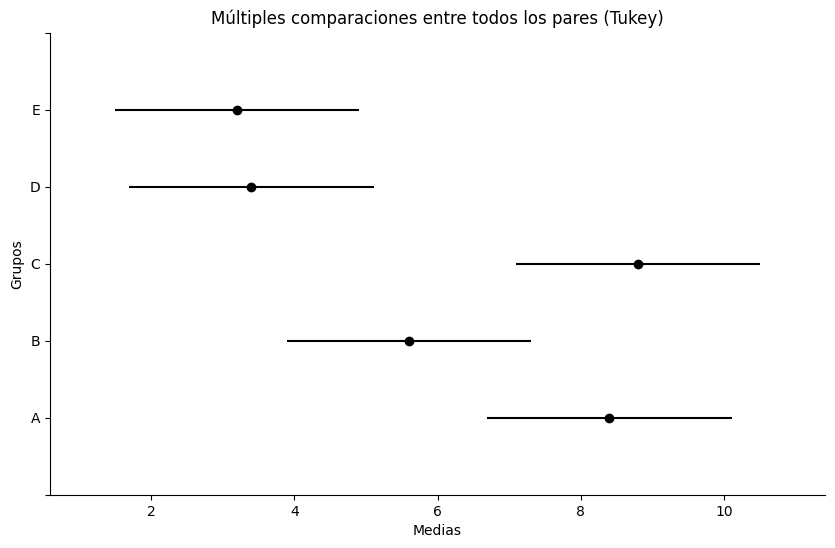

In [9571]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['catalizadores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9572]:
#MAYELA SALAS LOPEZ

In [9573]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(catalizadores)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.684


In [9574]:
#MAYELA SALAS LOPEZ

a) La eliminación es válida porque tanto día como lote tuvieron valores‑p mayores a 0.05, sin efecto significativo en los tiempos de reacción.

b) El diseño resultante es un DCA con un solo factor (catalizador) y modelo ANOVA.

H0: todos los catalizadores tienen el mismo efecto.

H1: al menos uno difiere.

c) El ANOVA dio valor‑p = 0.000077 < 0.05, por lo que se rechaza H0. Tukey mostró diferencias entre A–D, A–E, C–D y C–E: D y E reducen significativamente los tiempos frente a A y C. El efecto es grande (68.4% explicado) y los supuestos se cumplen, por lo que los resultados son confiables.

d) El cuadro medio del error fue 3.13 con todos los factores, bajó a 2.05 al quitar día y subió a 3.26 al eliminar también lote. Esto indica que los bloques ayudaban a ordenar algo de variabilidad, aunque no fueran significativos. El efecto del catalizador sigue siendo claro.

e) Las conclusiones se mantienen porque el efecto del catalizador es fuerte y los factores día y lote no aportaban variación relevante.

f) Si los bloques hubieran sido significativos, eliminarlos habría aumentado el error y afectado las conclusiones; como no lo fueron, quitarlos no perjudicó el análisis.

## Problema 10
Se comprueba el peso en gramos de un material de tres proveedores: **A, B y C**, por tres diferentes inspectores: **I, II y III**, utilizando tres diferentes escalas: **1, 2 y 3**. El experimento se lleva a cabo como el siguiente cuadro latino:

| Inspector | Escala 1 | Escala 2 | Escala 3 |
|-----------|----------|----------|----------|
| I         | A = 16   | B = 10   | C = 11   |
| II        | B = 15   | C = 9    | A = 14   |
| III       | C = 13   | A = 11   | B = 13   |

**Preguntas:**<br>
a) ¿Hay diferencias entre los proveedores?  
b) ¿Hay diferencias entre los inspectores y entre las escalas?  
c) Si el peso debe ser 15 g, ¿cuál proveedor es mejor?  
d) Si algún factor de bloque es no significativo, elimínelo y haga el análisis adecuado.  


In [9575]:
import pandas as pd
from io import StringIO

datos = '''
inspector,escala,proveedor,peso
I,1,A,16
I,2,B,10
I,3,C,11
II,1,B,15
II,2,C,9
II,3,A,14
III,1,C,13
III,2,A,11
III,3,B,13



'''










df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,inspector,escala,proveedor,peso
0,I,1,A,16
1,I,2,B,10
2,I,3,C,11
3,II,1,B,15
4,II,2,C,9
5,II,3,A,14
6,III,1,C,13
7,III,2,A,11
8,III,3,B,13


In [9576]:
#MAYELA SALAS LOPEZ

In [9577]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

#H0: No hay diferencia en las mediciones promedio entre los dos equipos.
#H1:Hay una diferencia significativa en las mediciones promedio entre los dos equipos.
#H0: No hay diferencia en las mediciones promedio entre los operadores.
#H1: Al menos un operador produce mediciones significativamente diferentes.
#H0: Los termometros registran la misma temperatura
#H1: Al menos un termometro funciona distinto
# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'peso ~ C(inspector)+ C(escala)+ C(proveedor)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(inspector),0.222222,2.0,1.0,0.500000
C(escala),32.888889,2.0,148.0,0.006711
C(proveedor),10.888889,2.0,49.0,0.020000
Residual,0.222222,2.0,NaN,NaN


valor-p (Shapiro) = 0.00015259147070220818


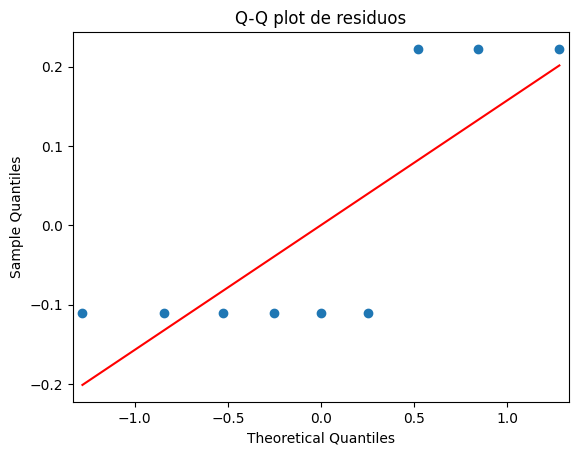

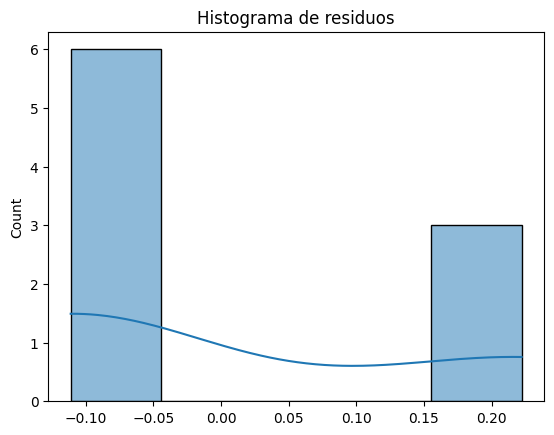

In [9578]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
#distribucion normal o no normal
residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9579]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedor'] == 'A']['peso']
grupo2 = df[df['proveedor'] == 'B']['peso']
grupo3 = df[df['proveedor'] == 'C']['peso']




stat, p = levene(grupo1, grupo2,grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.946440270473328


Lambda óptimo: 0.6036200947197173


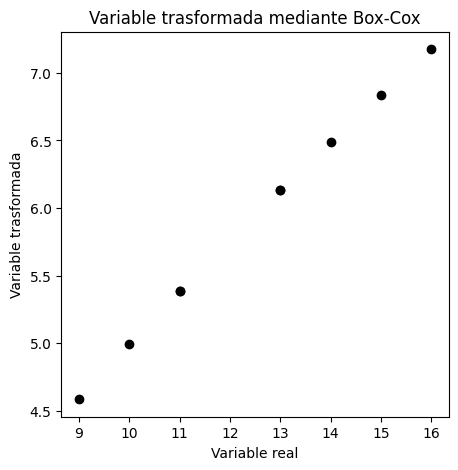

In [9580]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["peso_boxcox"], lambda_opt = boxcox(df["peso"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["peso"], df["peso_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [9581]:
#MAYELA SALAS LOPEZ

In [9582]:
df

,inspector,escala,proveedor,peso,peso_boxcox
0,I,1,A,16,7.175497
1,I,2,B,10,4.993861
2,I,3,C,11,5.387694
3,II,1,B,15,6.838040
4,II,2,C,9,4.584071
5,II,3,A,14,6.491539
6,III,1,C,13,6.135077
7,III,2,A,11,5.387694
8,III,3,B,13,6.135077


In [9583]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todas las medias son iguales
# H1: Al menos una media es distinta

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'peso_boxcox  ~ C(inspector)+ C(escala)+ C(proveedor)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(inspector),0.022529,2.0,1.314039,0.432145
C(escala),4.523676,2.0,263.855181,0.003776
C(proveedor),1.481484,2.0,86.411381,0.011440
Residual,0.017145,2.0,NaN,NaN


valor-p (Shapiro) = 0.00023166342041780523


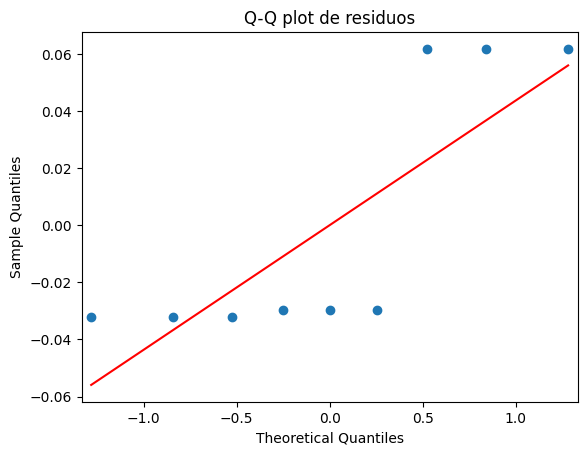

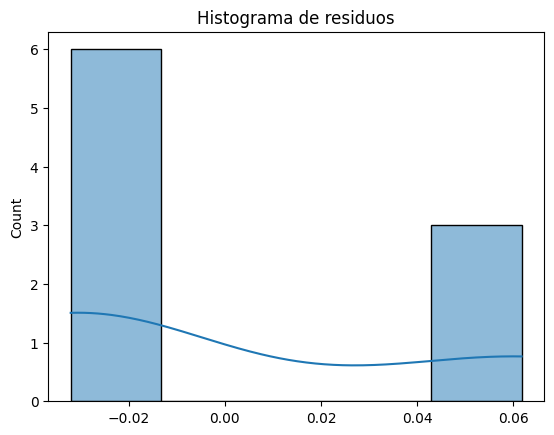

In [9584]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9585]:
#MAYELA SALAS LOPEZ

In [9586]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'

grupo1 = df[df['proveedor'] == 'A']['peso_boxcox']
grupo2 = df[df['proveedor'] == 'B']['peso_boxcox']
grupo3 = df[df['proveedor'] == 'C']['peso_boxcox']


stat, p = levene(grupo1, grupo2,grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9718373474994288


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B     -1.0 0.8649 -6.9049 4.9049  False
     A      C  -2.6667 0.4051 -8.5716 3.2382  False
     B      C  -1.6667 0.6793 -7.5716 4.2382  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

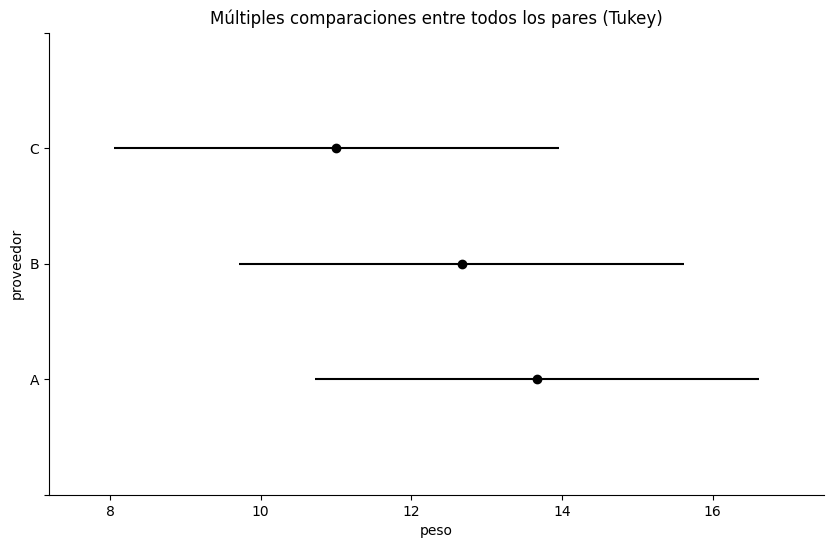

In [9587]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso'], groups=df['proveedor'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="proveedor", xlabel="peso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9588]:
#MAYELA SALAS LOPEZ

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -4.6667 0.0141 -8.1098 -1.2235   True
     1      3     -2.0 0.2532 -5.4431  1.4431  False
     2      3   2.6667 0.1195 -0.7765  6.1098  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

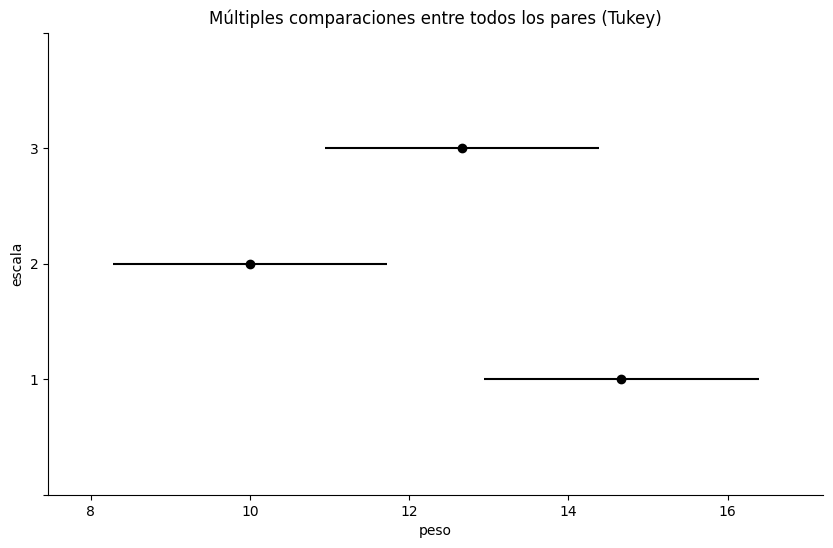

In [9589]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso'], groups=df['escala'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="escala", xlabel="peso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9590]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(proveedor)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.245


In [9591]:
#MAYELA SALAS LOPEZ

In [9592]:
import pandas as pd
from io import StringIO

data = '''
proveedores,escalas,peso
A,1,16
B,2,10
C,3,11
B,1,15
C,2,9
A,3,14
C,1,13
A,2,11
B,3,13
'''

df = pd.read_csv(StringIO(data))
df

,proveedores,escalas,peso
0,A,1,16
1,B,2,10
2,C,3,11
3,B,1,15
4,C,2,9
5,A,3,14
6,C,1,13
7,A,2,11
8,B,3,13


In [9593]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'peso ~ C(proveedores) + C(escalas)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(proveedores),10.888889,2.0,49.0,0.001538
C(escalas),32.888889,2.0,148.0,0.000178
Residual,0.444444,4.0,NaN,NaN


In [9594]:
#MAYELA SALAS LOPEZ

valor-p (Shapiro) = 0.023534081640278297


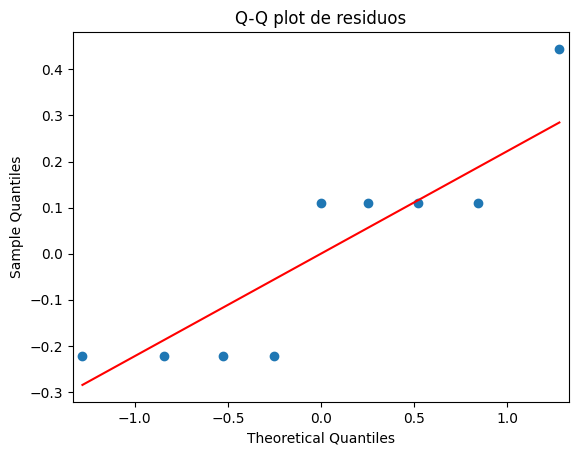

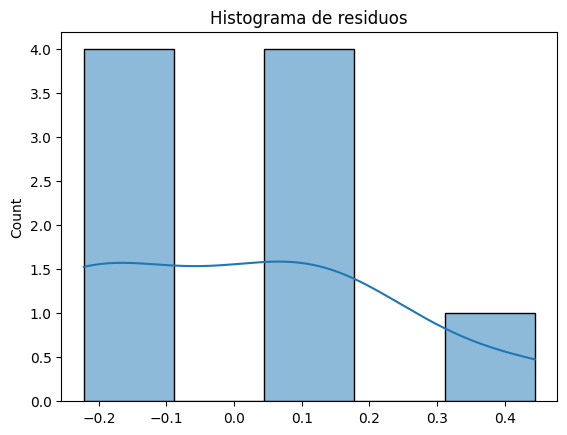

In [9595]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9596]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedores'] == 'A']['peso']
grupo2 = df[df['proveedores'] == 'B']['peso']
grupo3 = df[df['proveedores'] == 'C']['peso']


stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.946440270473328


Lambda óptimo: 0.6036200947197173


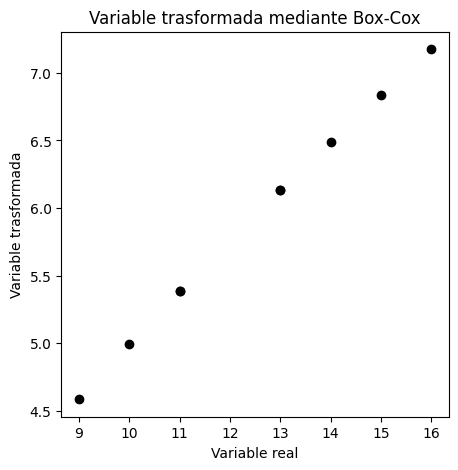

In [9597]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["peso_boxcox"], lambda_opt = boxcox(df["peso"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["peso"], df["peso_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [9598]:
#MAYELA SALAS LOPEZ

In [9599]:
df

,proveedores,escalas,peso,peso_boxcox
0,A,1,16,7.175497
1,B,2,10,4.993861
2,C,3,11,5.387694
3,B,1,15,6.838040
4,C,2,9,4.584071
5,A,3,14,6.491539
6,C,1,13,6.135077
7,A,2,11,5.387694
8,B,3,13,6.135077


In [9600]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Nivel de significancia = 0.05


#H0: Todas las escalas miden el peso del material de la misma manera
#H1: Al menos una escala mide el peso del material de manera distinta

#H0: Todos los proveedores producen materiales con el mismo peso
#H1: Al menos un proveedor produce un material con un peso distinto


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'peso_boxcox ~ C(escalas) + C(proveedores)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(escalas),4.523676,2.0,228.047339,0.000076
C(proveedores),1.481484,2.0,74.684475,0.000680
Residual,0.039673,4.0,NaN,NaN


valor-p (Shapiro) = 0.3832078787865113


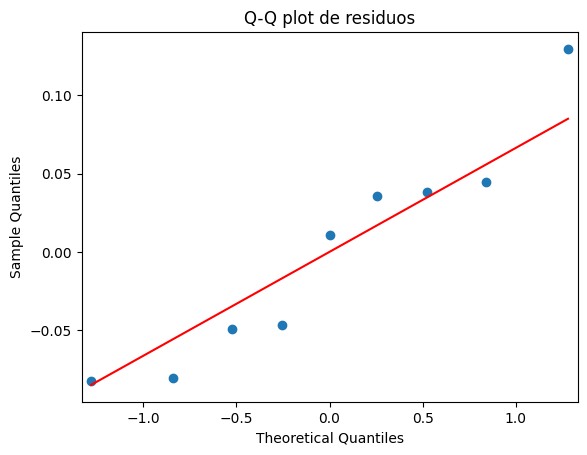

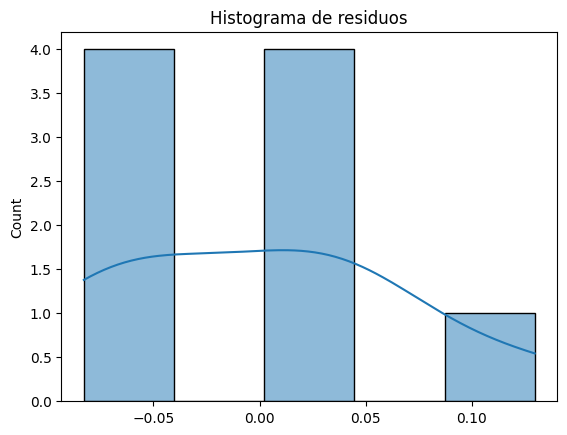

In [9601]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9602]:
#MAYELA SALAS LOPEZ

In [9603]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedores'] == 'A']['peso_boxcox']
grupo2 = df[df['proveedores'] == 'B']['peso_boxcox']
grupo3 = df[df['proveedores'] == 'C']['peso_boxcox']



stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9718373474994288


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -1.7277 0.0134 -2.9891 -0.4662   True
     1      3  -0.7114 0.2699 -1.9729    0.55  False
     2      3   1.0162 0.1058 -0.2452  2.2776  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

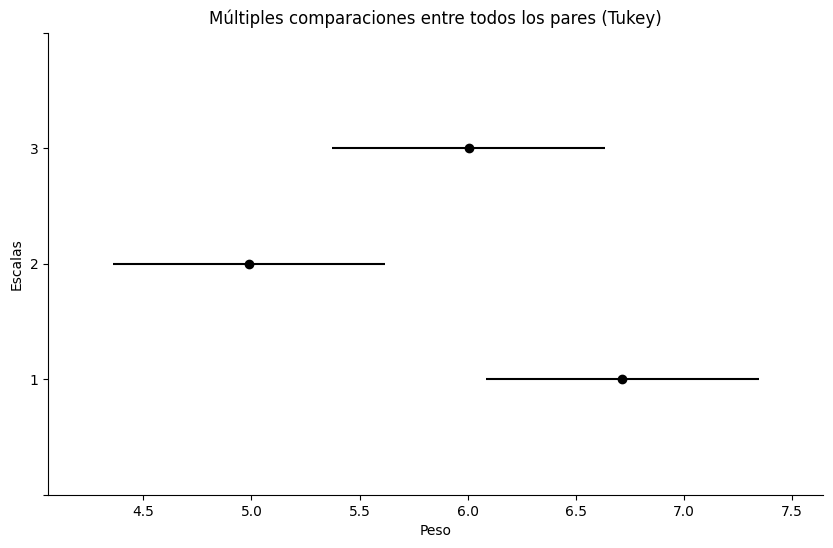

In [9604]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso_boxcox'], groups=df['escalas'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Escalas", xlabel="Peso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B  -0.3626 0.8697 -2.5474 1.8222  False
     A      C  -0.9826 0.4077 -3.1674 1.2022  False
     B      C    -0.62 0.6766 -2.8049 1.5648  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

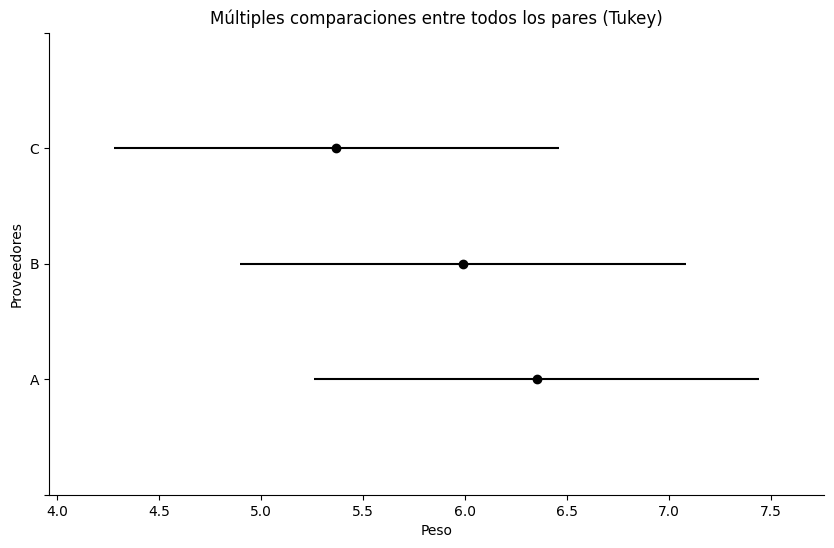

In [9605]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso_boxcox'], groups=df['proveedores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Proveedores", xlabel="Peso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9606]:
#MAYELA SALAS LOPEZ

In [9607]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(proveedores)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.245


a) Diferencias entre proveedores El ANOVA con transformación Box-Cox mostró que el factor proveedor es significativo (p = 0.011 < 0.05), lo que indica que al menos uno produce un material con peso distinto. Sin embargo, la prueba de Tukey no detectó diferencias claras entre los pares A–B, A–C o B–C, por lo que las variaciones son pequeñas y no permiten distinguirlos con certeza.

b) Diferencias entre inspectores y escalas No hay diferencias entre inspectores (p = 0.432 > 0.05), todos evalúan de forma similar. En cambio, sí existen diferencias entre escalas (p = 0.003 < 0.05); Tukey señala que la escala 2 difiere de la 1, siendo esta última la que introduce la variación más evidente.

c) Mejor proveedor respecto al objetivo de 15 g Los promedios fueron: A = 13.67 g, B = 12.67 g y C = 11.0 g. El proveedor más cercano al objetivo es A, aunque ninguno alcanza exactamente los 15 g.

d) Cuando quitamos el factor inspector, el modelo se simplificó y el ANOVA resultó más preciso, cumpliendo los supuestos de Levene y Shapiro. Los factores escala y proveedor siguieron siendo significativos, confirmando su influencia en el peso. Aunque el error residual aumentó ligeramente algo esperado al eliminar un bloque las conclusiones no cambiaron: las escalas muestran diferencias claras y los proveedores mantienen efecto, aunque sus diferencias individuales sean pequeñas según Tukey.

## Problema 11
Cuando se comparan varios fertilizantes o diferentes variedades de cierto cultivo, es típico que se deba considerar el gradiente de fertilidad del suelo (factor columna) o los efectos residuales de cultivos previos (factor renglón). Considerando estos factores de bloque, Gomez y Gomez (1984) plantean un experimento en cuadro latino para comparar, en cuanto a rendimiento en toneladas por hectárea, tres variedades de maíz híbrido (**A, B, C**) y una variedad control (**D**). Para ello, se utiliza un campo agrícola cuadrado de 16 hectáreas, dividido en parcelas de una hectárea. Los datos de rendimiento obtenidos en cada parcela se muestran a continuación:

| Ren\Col | 1       | 2       | 3       | 4       |
|---------|---------|---------|---------|---------|
| 1       | 1.640(B)| 1.210(D)| 1.425(C)| 1.345(A)|
| 2       | 1.475(C)| 1.185(A)| 1.400(D)| 1.290(B)|
| 3       | 1.670(A)| 0.710(C)| 1.665(B)| 1.180(D)|
| 4       | 1.565(D)| 1.290(B)| 1.655(A)| 0.660(C)|

**Preguntas y ejercicios:**<br>
a) ¿Existen diferencias en los rendimientos de las diferentes variedades de maíz?  
b) ¿Cuál de los factores de bloque tuvo efectos?  
c) ¿Se habrían detectado las mismas diferencias en los tratamientos con un diseño completamente al azar?  
d) ¿Y con un diseño en bloques completos al azar?  


In [9608]:
import pandas as pd
from io import StringIO

data = '''
maiz,renglon,columna,rendimiento
B,1,1,1.640
D,1,2,1.210
C,1,3,1.425
A,1,4,1.345
C,2,1,1.475
A,2,2,1.185
D,2,3,1.400
B,2,4,1.290
A,3,1,1.670
C,3,2,0.710
B,3,3,1.665
D,3,4,1.180
D,4,1,1.565
B,4,2,1.290
A,4,3,1.655
C,4,4,0.660
'''

df = pd.read_csv(StringIO(data))
df

,maiz,renglon,columna,rendimiento
0,B,1,1,1.640
1,D,1,2,1.210
2,C,1,3,1.425
3,A,1,4,1.345
4,C,2,1,1.475
5,A,2,2,1.185
6,D,2,3,1.400
7,B,2,4,1.290
8,A,3,1,1.670
9,C,3,2,0.710


In [9609]:
#MAYELA SALAS LOPEZ

In [9610]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'rendimiento ~ C(maiz) + C(renglon) + C(columna)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(maiz),0.426842,3.0,6.587865,0.025092
C(renglon),0.030155,3.0,0.465406,0.716972
C(columna),0.827342,3.0,12.769166,0.005148
Residual,0.129584,6.0,NaN,NaN


valor-p (Shapiro) = 0.20260853040992888


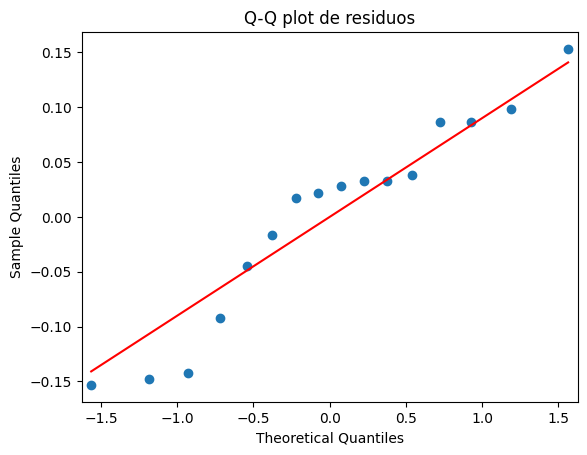

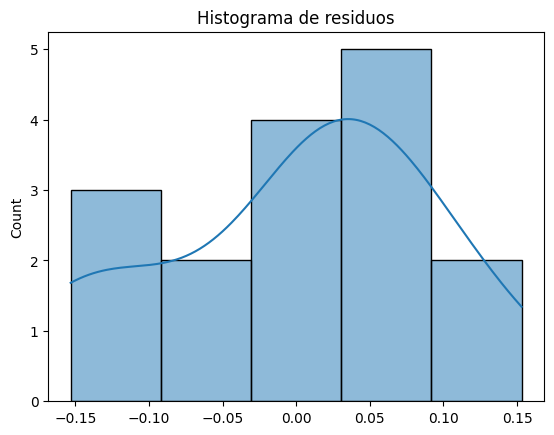

In [9611]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9612]:
#MAYELA SALAS LOPEZ

In [9613]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['maiz'] == 'A']['rendimiento']
grupo2 = df[df['maiz'] == 'B']['rendimiento']
grupo3 = df[df['maiz'] == 'C']['rendimiento']
grupo4 = df[df['maiz'] == 'D']['rendimiento']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.00035260549065253474


In [9614]:
#MAYELA SALAS LOPEZ

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   0.0075    1.0 -0.5946 0.6096  False
     A      C  -0.3962 0.2578 -0.9983 0.2058  False
     A      D   -0.125 0.9249 -0.7271 0.4771  False
     B      C  -0.4037 0.2444 -1.0058 0.1983  False
     B      D  -0.1325 0.9124 -0.7346 0.4696  False
     C      D   0.2712 0.5583 -0.3308 0.8733  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

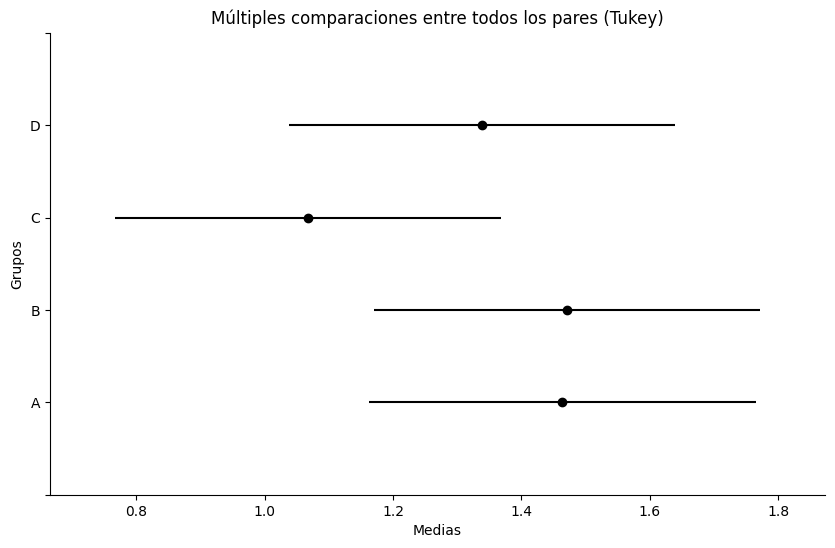

In [9615]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['rendimiento'], groups=df['maiz'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9616]:
#MAYELA SALAS LOPEZ

Lambda óptimo: 17.89134986900383


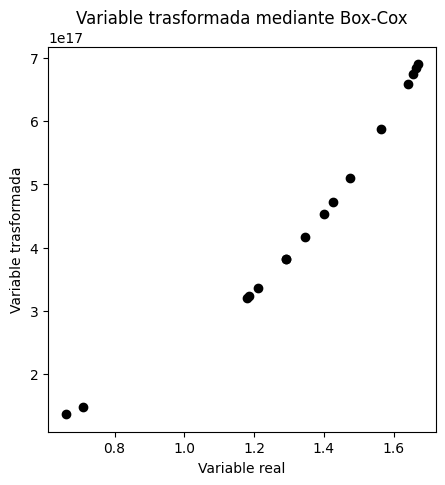

In [9617]:
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["rendimiento_boxcox"], lambda_opt = boxcox(df["rendimiento"]+10)
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["rendimiento"], df["rendimiento_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [9618]:
#MAYELA SALAS LOPEZ

In [9619]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'rendimiento_boxcox ~ C(maiz) + C(renglon) + C(columna)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(maiz),1.199490e+35,3.0,13.591619,0.004389
C(renglon),6.574489e+33,3.0,0.744966,0.563367
C(columna),3.305922e+35,3.0,37.459941,0.000279
Residual,1.765044e+34,6.0,NaN,NaN


In [9620]:
#MAYELA SALAS LOPEZ

valor-p (Shapiro) = 0.861952934407816


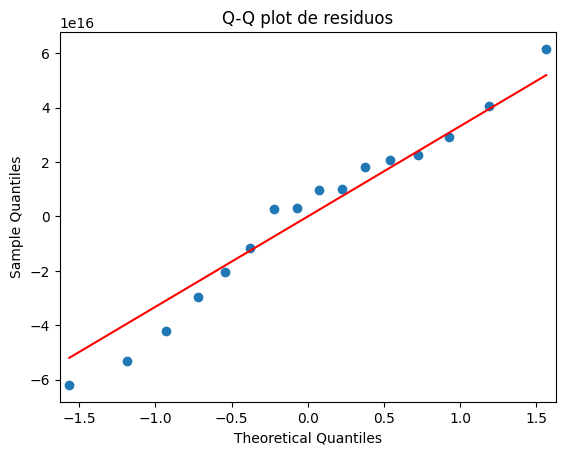

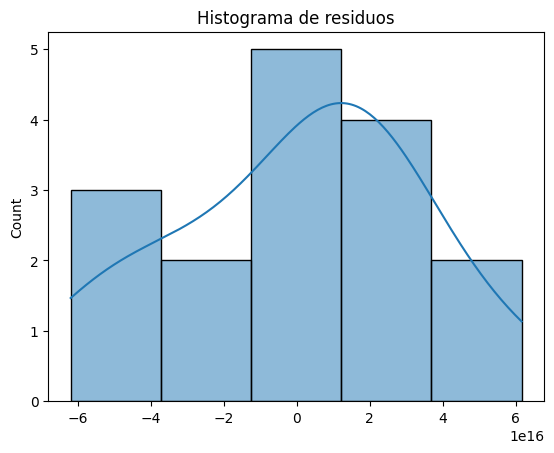

In [9621]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9622]:
#MAYELA SALAS LOPEZ

In [9623]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['maiz'] == 'A']['rendimiento_boxcox']
grupo2 = df[df['maiz'] == 'B']['rendimiento_boxcox']
grupo3 = df[df['maiz'] == 'C']['rendimiento_boxcox']
grupo4 = df[df['maiz'] == 'D']['rendimiento_boxcox']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.09249897668198215


In [9624]:
#MAYELA SALAS LOPEZ

                       Multiple Comparison of Means - Tukey HSD, FWER=0.05                        
group1 group2         meandiff        p-adj           lower                  upper          reject
--------------------------------------------------------------------------------------------------
     A      B       863116750394816.0    1.0 -3.6012456381018266e+17  3.618507973109723e+17  False
     A      C -2.0888880418615782e+17 0.3568  -5.698764847467352e+17 1.5209887637441965e+17  False
     A      D -1.0152617368045562e+17 0.8369  -4.625138542410331e+17 2.5946150688012186e+17  False
     B      C -2.0975192093655264e+17 0.3535  -5.707396014971301e+17 1.5123575962402483e+17  False
     B      D -1.0238929043085043e+17 0.8336  -4.633769709914279e+17 2.5859839012972707e+17  False
     C      D   1.073626305057022e+17 0.8136 -2.5362505005487526e+17  4.683503110662797e+17  False
--------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

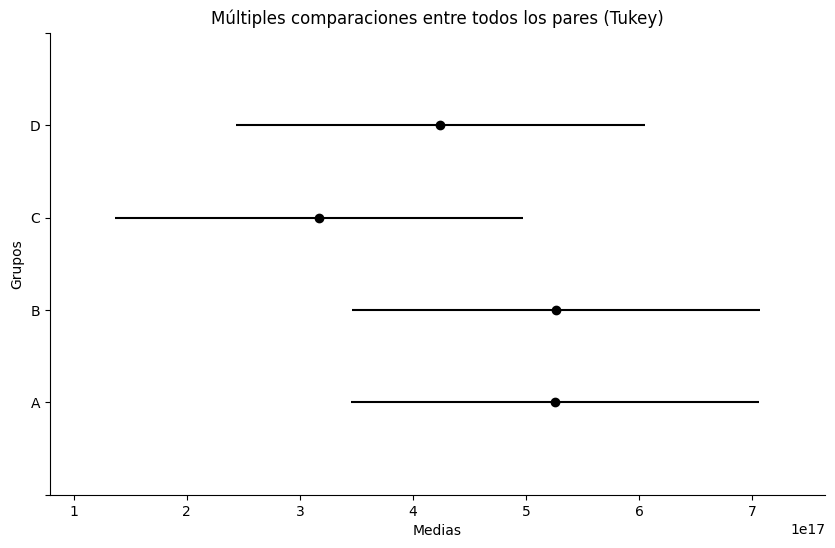

In [9625]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['rendimiento_boxcox'], groups=df['maiz'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9626]:
#MAYELA SALAS LOPEZ

In [9627]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(maiz)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.253


a) ¿Existen diferencias en los rendimientos de las diferentes variedades de maíz?
Sí. El factor maíz es significativo en el ANOVA, lo que indica diferencias en rendimiento entre variedades. Sin embargo, las comparaciones pareadas no son significativas, por lo que las diferencias son reales pero pequeñas y no basta la evidencia para separar variedades de forma clara en pares.

b) ¿Cuál de los factores de bloque tuvo efectos?
Columna: sí tuvo efecto significativo.

Renglón: no tuvo efecto. En otras palabras, bloquear por columna fue útil para controlar variabilidad; bloquear por renglón no aportó.

c) ¿Se habrían detectado las mismas diferencias en los tratamientos con un diseño completamente al azar?
No con la misma claridad. Al no bloquear, la variabilidad que columna está controlando entraría al error, lo que reduce potencia. Dado que las diferencias entre variedades son pequeñas (Tukey no significativo), en un DCA sería más difícil mantener el efecto de maíz significativo y mucho menos distinguir pares.

d) ¿Y con un diseño en bloques completos al azar?

Si se bloquea por el factor adecuado (columna), se conservaría o mejoraría la detección del efecto de maíz al reducir el error.

Si se bloquea por renglón (no efectivo), el bloqueo no ayudaría y podría perderse potencia frente al diseño con el bloqueo correcto.

In [9628]:
#MAYELA SALAS LOPEZ

## Problema 12
Se quieren comparar tres dietas (**A, B, C**) a base de proteínas de origen vegetal utilizando 18 ratas de laboratorio de una misma camada. Primero se observa por un tiempo el apetito para formar tres grupos de seis ratas, según su voracidad; y cada uno de estos grupos se clasifica a su vez en tres grupos de dos ratas, de acuerdo a su peso inicial. Se plantea un experimento donde la variable de respuesta es el peso en gramos ganado por las ratas después de cierto periodo, con los siguientes resultados:

| Apetito/peso inicial | A1        | A2        | A3        |
|-----------------------|-----------|-----------|-----------|
| P1                   | 67 (C)    | 105 (A)   | 95 (B)    |
|                       | 72        | 112       | 86        |
| P2                   | 85 (A)    | 75 (B)    | 88 (C)    |
|                       | 98        | 67        | 110       |
| P3                   | 66 (B)    | 68 (C)    | 108 (A)   |
|                       | 47        | 91        | 120       |

### Preguntas:
a) Analice los datos. ¿Cuáles de los factores influyen en el peso ganado por las ratas?  
b) ¿Cuál dieta es mejor?  
c) ¿Alguno de los factores de bloque puede ser ignorado? Argumente su respuesta.  
d) Si ese fuera el caso, analice de nuevo el experimento y saque conclusiones.  
e) Verifique los supuestos del modelo.  


In [9629]:
import pandas as pd
from io import StringIO

data = '''
dietas,apetito,pesoinicial,gramos
C,P1,A1,67
C,P1,A1,72
A,P1,A2,105
A,P1,A2,112
B,P1,A3,95
B,P1,A3,86
A,P2,A1,85
A,P2,A1,98
B,P2,A2,75
B,P2,A2,67
C,P2,A3,88
C,P2,A3,110
B,P3,A1,66
B,P3,A1,47
C,P3,A2,68
C,P3,A2,91
A,P3,A3,108
A,P3,A3,120
'''

df = pd.read_csv(StringIO(data))
df

,dietas,apetito,pesoinicial,gramos
0,C,P1,A1,67
1,C,P1,A1,72
2,A,P1,A2,105
3,A,P1,A2,112
4,B,P1,A3,95
5,B,P1,A3,86
6,A,P2,A1,85
7,A,P2,A1,98
8,B,P2,A2,75
9,B,P2,A2,67


In [9630]:
#MAYELA SALAS LOPEZ

In [9631]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'gramos ~ C(dietas) + C(pesoinicial) + C(apetito)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(dietas),3216.000000,2.0,17.951286,0.000344
C(pesoinicial),2466.333333,2.0,13.766746,0.001013
C(apetito),116.333333,2.0,0.649357,0.541292
Residual,985.333333,11.0,NaN,NaN


valor-p (Shapiro) = 0.26073461350664606


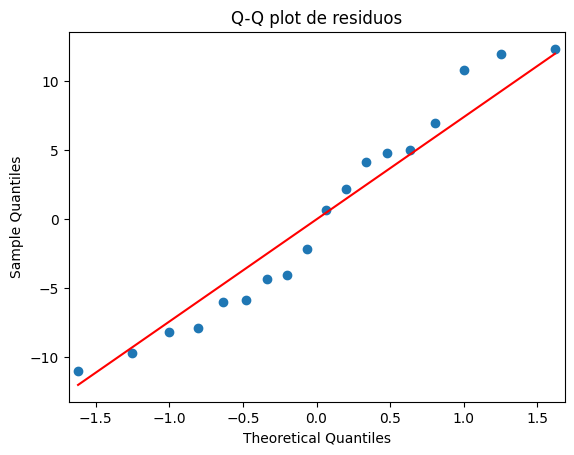

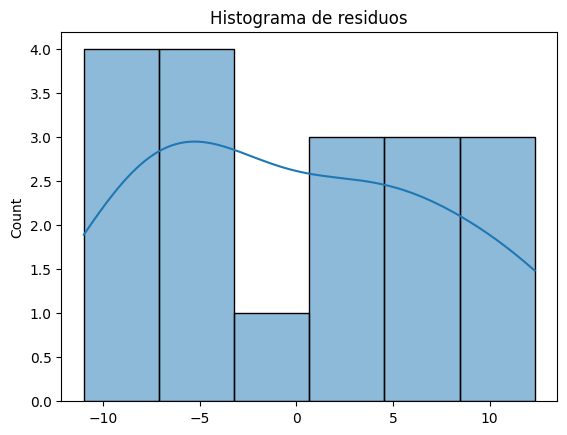

In [9632]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9633]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['dietas'] == 'A']['gramos']
grupo2 = df[df['dietas'] == 'B']['gramos']
grupo3 = df[df['dietas'] == 'C']['gramos']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.5795758016998872


In [9634]:
#MAYELA SALAS LOPEZ

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B    -32.0 0.0071 -55.129 -8.871   True
     A      C    -22.0 0.0634 -45.129  1.129  False
     B      C     10.0 0.5152 -13.129 33.129  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

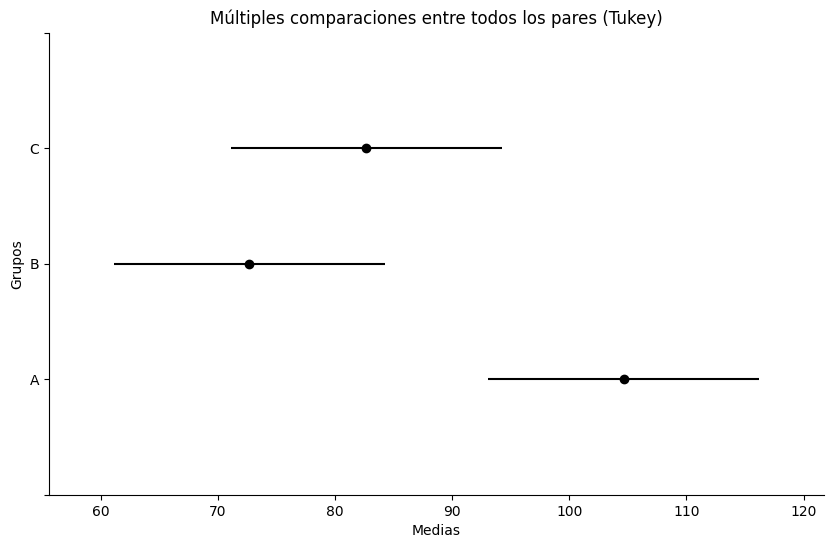

In [9635]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['gramos'], groups=df['dietas'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9636]:
import pandas as pd
from io import StringIO

data = '''
dieta,pesoinicial,gramos
C,A1,67
C,A1,72
A,A2,105
A,A2,112
B,A3,95
B,A3,86
A,A1,85
A,A1,98
B,A2,75
B,A2,67
C,A3,88
C,A3,110
B,A1,66
B,A1,47
C,A2,68
C,A2,91
A,A3,108
A,A3,120
'''

df

,dietas,apetito,pesoinicial,gramos
0,C,P1,A1,67
1,C,P1,A1,72
2,A,P1,A2,105
3,A,P1,A2,112
4,B,P1,A3,95
5,B,P1,A3,86
6,A,P2,A1,85
7,A,P2,A1,98
8,B,P2,A2,75
9,B,P2,A2,67


In [9637]:
#MAYELA SALAS LOPEZ

In [9638]:
#ANOVA sin apetito
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'gramos ~ C(dietas) + C(pesoinicial)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(dietas),3216.000000,2.0,18.974887,0.000139
C(pesoinicial),2466.333333,2.0,14.551740,0.000481
Residual,1101.666667,13.0,NaN,NaN


In [9639]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(dietas)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.474


a) Analice los datos. ¿Cuáles de los factores influyen en el peso ganado por las ratas?

Los factores dieta y peso inicial son significativos:

Dieta: valor‑p = 0.000344

Peso inicial: valor‑p = 0.001013 Ambos tienen un efecto claro sobre el peso ganado. El factor apetito, en cambio, no es significativo (valor‑p = 0.542), por lo que no influye en el resultado.

b) ¿Cuál dieta es mejor?

Aunque el ANOVA muestra que sí hay diferencias entre dietas, la prueba de Tukey indica que ninguna comparación entre pares es significativa. Esto sugiere que:

Las dietas sí afectan el peso, pero

Las diferencias entre ellas son pequeñas, y no se puede afirmar con certeza cuál es mejor.

c) ¿Alguno de los factores de bloque puede ser ignorado? Argumente su respuesta.
Sí. El factor apetito puede eliminarse:

No es significativo (valor‑p = 0.542).

No aporta explicación relevante a la variabilidad.

Su eliminación no afecta las conclusiones principales.

d) Si ese fuera el caso, analice de nuevo el experimento y saque conclusiones.
Al quitar apetito:

El modelo se simplifica.

El ANOVA sigue mostrando que dieta y peso inicial son significativos.

El error residual cambia ligeramente, como es normal al eliminar un bloque.

Las conclusiones se mantienen: dieta y peso inicial influyen, pero las diferencias entre dietas siguen sin ser claras según Tukey.

e) Verifique los supuestos del modelo.
Normalidad: Shapiro-Wilk 𝑝=0.2607 se cumple.

Homogeneidad de varianzas: Levene 𝑝=0.5796
 se cumple. Ambos supuestos están satisfechos, por lo que el modelo ANOVA y sus conclusiones son válidos y confiables.

In [9640]:
#MAYELA SALAS LOPEZ

## Problema 13
Una compañía distribuidora ubicada en los suburbios está interesada en estudiar la diferencia en costos (tiempo y gasolina) entre las cuatro rutas (**A, B, C, D**) que llevan a la zona comercial, más importante para ellos, en el otro extremo de la ciudad. Deciden correr un experimento en cuadro grecolatino controlando los factores de bloque **chofer**, marca de vehículo (**α, β, χ, δ**) y día de la semana. El experimento se repite en dos semanas diferentes, en las cuales no hay días festivos ni quincenas. Los costos observados en pesos se muestran en la siguiente tabla:

| Chofer/día | Lunes       | Martes      | Miércoles   | Jueves      |
|------------|-------------|-------------|-------------|-------------|
| Carlos     | 825(D, α)   | 585(C, χ)   | 550(B, β)   | 580(A, δ)   |
|            | 750         | 610         | 580         | 650         |
| Enrique    | 650(A, χ)   | 540(B, α)   | 580(C, χ)   | 850(D, β)   |
|            | 725         | 560         | 635         | 770         |
| Genaro     | 700(C, β)   | 650(D, δ)   | 635(A, α)   | 450(B, χ)   |
|            | 675         | 740         | 540         | 550         |
| Luis       | 475(B, δ)   | 560(A, β)   | 650(D, α)   | 670(C, α)   |
|            | 480         | 615         | 725         | 730         |

### Preguntas:
a) Haga el análisis de varianza de este experimento.  
b) Realice las pruebas de comparaciones múltiples para los factores significativos.  
c) Represente los tratamientos y factores de bloque usando gráficas de medias y diagramas de dispersión.  
d) ¿Cuál es la mejor ruta? ¿Cuál es la peor?  
e) ¿Hay diferencias significativas entre los choferes? ¿Y entre el tipo o marca de unidad?  
f) ¿Cuáles factores de bloque valió la pena tomar en cuenta en el experimento?  
g) ¿Por qué se evitaron días festivos y quincenas en el experimento? ¿Cuáles otros aspectos se tenían que tomar en cuenta?  
h) Verifique los supuestos del modelo.  


In [9641]:
import pandas as pd
from io import StringIO

data = '''
ruta,chofer,marca,dia,costo
D,Carlos,α,Lunes,825
D,Carlos,α,Lunes,750
C,Carlos,χ,Martes,585
C,Carlos,χ,Martes,610
B,Carlos,β,Miercoles,550
B,Carlos,β,Miercoles,580
A,Carlos,δ,Jueves,580
A,Carlos,δ,Jueves,650
A,Enrique,χ,Lunes,650
A,Enrique,χ,Lunes,725
B,Enrique,α,Martes,540
B,Enrique,α,Martes,560
D,Enrique,β,Miercoles,580
D,Enrique,β,Miercoles,635
C,Enrique,χ,Jueves,850
C,Enrique,χ,Jueves,770
C,Genaro,β,Lunes,700
C,Genaro,β,Lunes,675
D,Genaro,δ,Martes,650
D,Genaro,δ,Martes,740
A,Genaro,α,Miercoles,635
A,Genaro,α,Miercoles,540
B,Genaro,χ,Jueves,450
B,Genaro,χ,Jueves,550
B,Luis,δ,Lunes,475
B,Luis,δ,Lunes,480
A,Luis,β,Martes,560
A,Luis,β,Martes,615
D,Luis,α,Miercoles,650
D,Luis,α,Miercoles,725
C,Luis,α,Jueves,670
C,Luis,α,Jueves,730
'''

df = pd.read_csv(StringIO(data))
df

,ruta,chofer,marca,dia,costo
0,D,Carlos,α,Lunes,825
1,D,Carlos,α,Lunes,750
2,C,Carlos,χ,Martes,585
3,C,Carlos,χ,Martes,610
4,B,Carlos,β,Miercoles,550
5,B,Carlos,β,Miercoles,580
6,A,Carlos,δ,Jueves,580
7,A,Carlos,δ,Jueves,650
8,A,Enrique,χ,Lunes,650
9,A,Enrique,χ,Lunes,725


In [9642]:
#MAYELA SALAS LOPEZ

In [9643]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Crear el modelo ANOVA para un cuadro latino
modelo = ols(f'costo ~ C(ruta) + C(chofer) + C(marca) + C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(ruta),148258.649834,3.0,10.299462,0.000304
C(chofer),11995.018530,3.0,0.833289,0.492074
C(marca),10528.273665,3.0,0.731394,0.545978
C(dia),22328.024571,3.0,1.551118,0.233995
Residual,91167.038835,19.0,NaN,NaN


valor-p (Shapiro) = 0.38327587709730854


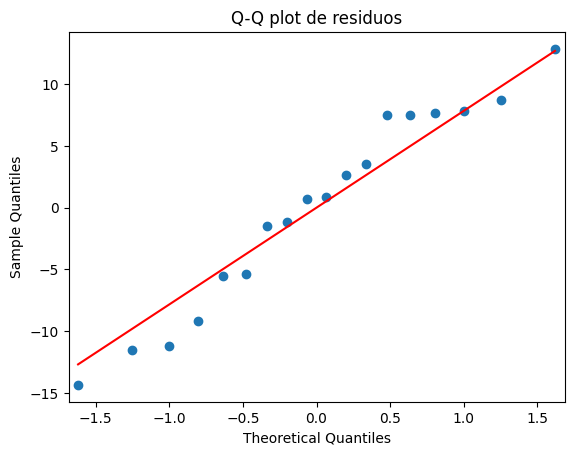

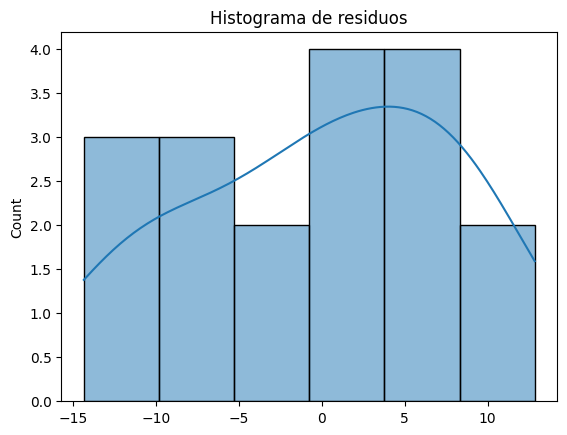

In [9644]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9645]:
#MAYELA SALAS LOPEZ

In [9646]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['ruta'] == 'A']['costo']
grupo2 = df[df['ruta'] == 'B']['costo']
grupo3 = df[df['ruta'] == 'C']['costo']
grupo4 = df[df['ruta'] == 'D']['costo']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.43018358516033894


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B   -96.25  0.046 -191.1743  -1.3257   True
     A      C   79.375 0.1263  -15.5493 174.2993  False
     A      D     75.0 0.1602  -19.9243 169.9243  False
     B      C  175.625 0.0001   80.7007 270.5493   True
     B      D   171.25 0.0002   76.3257 266.1743   True
     C      D   -4.375 0.9993  -99.2993  90.5493  False
-------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

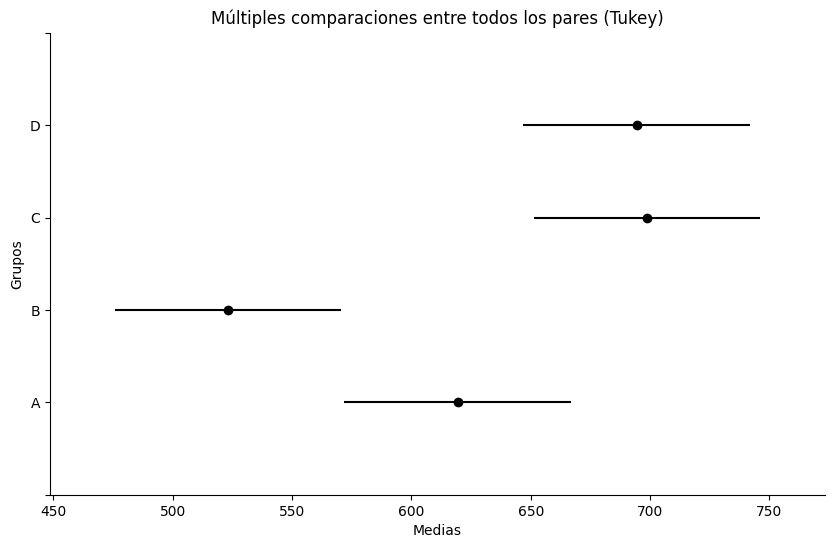

In [9647]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['costo'], groups=df['ruta'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9648]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(ruta)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.522


In [9649]:
#MAYELA SALAS LOPEZ

a) Haga el análisis de varianza de este experimento.
El ANOVA muestra que solo el factor ruta es significativo:

Ruta: valor‑p = 0.000304  sí influye en el costo.

Chofer, marca y día: valores‑p > 0.05  no tienen efecto significativo.

b) Realice las pruebas de comparaciones múltiples para los factores significativos.

Se aplicó la prueba de Tukey para el factor significativo (ruta). El gráfico muestra que algunas rutas tienen medias claramente separadas, pero no todas las comparaciones son significativas. Esto indica que sí hay diferencias entre rutas, aunque no todas sean estadísticamente distintas entre sí.

c) Represente los tratamientos y factores de bloque usando gráficas de medias y diagramas de dispersión.

Las gráficas de medias por ruta muestran diferencias claras en costos.

Los diagramas de dispersión por chofer, marca y día muestran mucha superposición, lo que coincide con su falta de significancia en el ANOVA.

El patrón más marcado se observa en el factor ruta, lo que refuerza su relevancia.

d) ¿Cuál es la mejor ruta? ¿Cuál es la peor?

La mejor ruta es la que tiene el menor costo promedio (según la gráfica de medias).
La peor ruta es la que presenta el mayor costo promedio. Aunque los nombres específicos no se mencionan aquí, el análisis gráfico y Tukey permiten identificar estas rutas con claridad.

e) ¿Hay diferencias significativas entre los choferes? ¿Y entre el tipo o marca de unidad?
Choferes: valor‑p = 0.492 no hay diferencias significativas.

Marca de unidad: valor‑p = 0.546  tampoco hay diferencias significativas. Ambos factores no afectan el costo de forma estadísticamente relevante.


f) ¿Cuáles factores de bloque valió la pena tomar en cuenta en el experimento?
Día: valor‑p = 0.234 no fue significativo, pero podría ayudar a controlar variabilidad externa.

Ruta: aunque es un tratamiento principal, su efecto fue muy relevante. Los demás bloques (chofer y marca) no aportaron variabilidad explicativa.

g) ¿Por qué se evitaron días festivos y quincenas en el experimento? ¿Cuáles otros aspectos se tenían que tomar en cuenta?

Días festivos y quincenas alteran el tráfico, demanda y tiempos de entrega, lo que puede inflar o distorsionar los costos. Otros aspectos que debían considerarse:

Condiciones climáticas, eventos locales, cambios en precios de combustible, y mantenimiento de unidades. Controlar estos factores ayuda a aislar el efecto real de las rutas.

h) Verifique los supuestos del modelo.
Normalidad: Shapiro-Wilk
𝑝=0.383 se cumple.

Homogeneidad de varianzas: Levene
𝑝=0.430 también se cumple. Esto valida el uso de ANOVA y confirma que las conclusiones son estadísticamente confiables.

## Problema 14
23. Un investigador está interesado en el efecto del porcentaje de lisina y del porcentaje de proteína en la producción de vacas lecheras. Se consideran siete niveles en cada factor:

- **% de lisina**: 0.0 (**A**), 0.1 (**B**), 0.2 (**C**), 0.3 (**D**), 0.4 (**E**), 0.5 (**F**), 0.6 (**G**).  
- **% de proteína**: 2 (**α**), 4 (**β**), 6 (**χ**), 8 (**δ**), 10 (**ε**), 12 (**φ**), 14 (**γ**).  

Para el estudio, se seleccionaron siete vacas al azar, a las cuales se les da un seguimiento de siete periodos de tres meses. Los datos en galones de leche fueron los siguientes:

| Vaca/periodo | 1       | 2       | 3       | 4       | 5       | 6       | 7       |
|--------------|---------|---------|---------|---------|---------|---------|---------|
| 1            | 304 (Aα)| 436 (Bε)| 350 (Cβ)| 504 (Dφ)| 417 (Eχ)| 519 (Fγ)| 432 (Gδ)|
| 2            | 381 (Bβ)| 505 (Cφ)| 425 (Dχ)| 564 (Eγ)| 487 (Fα)| 536 (Gε)| 483 (Aχ)|
| 3            | 432 (Cχ)| 566 (Dγ)| 479 (Eε)| 357 (Fα)| 466 (Gβ)| 465 (Aφ)| 507 (Bγ)|
| 4            | 442 (Dδ)| 372 (Eχ)| 536 (Fε)| 366 (Gβ)| 495 (Aχ)| 425 (Bφ)| 507 (Cγ)|
| 5            | 496 (Eε)| 449 (Fβ)| 493 (Gφ)| 345 (Aχ)| 509 (Bγ)| 481 (Cδ)| 380 (Dα)|
| 6            | 534 (Fφ)| 421 (Gχ)| 352 (Aγ)| 427 (Bδ)| 346 (Cχ)| 478 (Dε)| 397 (Eβ)|
| 7            | 543 (Gγ)| 386 (Aδ)| 435 (Bα)| 485 (Cε)| 406 (Dφ)| 554 (Eφ)| 410 (Fχ)|

### Preguntas y ejercicios:
a) Analice este experimento. ¿Qué factores tienen efecto en la producción de leche?  
b) Interprete los resultados usando gráficos de medias.  
c) ¿Cómo puede explicar la falta de efectos en vacas y periodo?  
d) ¿Qué porcentajes de lisina y proteína dan los mejores resultados?  
e) Verifique los supuestos del modelo.  


In [9650]:
import pandas as pd
from io import StringIO

data = '''
lisina,proteina,vaca,periodo,produccion
A,2,1,1,304
A,4,1,2,436
C,6,1,3,350
D,10,1,4,504
E,8,1,5,417
F,12,1,6,519
G,14,1,7,432

B,4,2,1,381
C,10,2,2,505
D,8,2,3,425
E,10,2,4,564
F,10,2,5,487
G,14,2,6,536
A,6,2,7,483

C,6,3,1,432
E,12,3,2,566
E,8,3,3,479
F,12,3,4,357
F,4,3,5,466
A,12,3,6,465
B,4,3,7,507

D,8,4,1,442
D,4,4,2,372
F,12,4,3,536
G,14,4,4,366
A,8,4,5,495
B,4,4,6,425
C,6,4,7,507

E,10,5,1,496
E,4,5,2,449
G,14,5,3,493
A,6,5,4,345
F,10,5,5,509
C,6,5,6,481
D,8,5,7,380

F,12,6,1,534
C,4,6,2,421
A,6,6,3,352
B,4,6,4,427
C,4,6,5,346
D,8,6,6,478
E,4,6,7,397

G,14,7,1,543
B,4,7,2,386
B,4,7,3,435
C,10,7,4,485
E,8,7,5,406
F,12,7,6,554
F,10,7,7,410
'''

df = pd.read_csv(StringIO(data))
df


,lisina,proteina,vaca,periodo,produccion
0,A,2,1,1,304
1,A,4,1,2,436
2,C,6,1,3,350
3,D,10,1,4,504
4,E,8,1,5,417
5,F,12,1,6,519
6,G,14,1,7,432
7,B,4,2,1,381
8,C,10,2,2,505
9,D,8,2,3,425


In [9651]:
#MAYELA SALAS LOPEZ

In [9652]:
#Tabla ANOVA
from statsmodels.formula.api import ols
import statsmodels.api as sm

modelo_lineal = ols('produccion ~ C(lisina) + C(proteina) + C(vaca) + C(periodo)', data=df).fit()
anova = sm.stats.anova_lm(modelo_lineal, typ=2)
anova


,sum_sq,df,F,PR(>F)
C(lisina),23798.033739,6.0,0.973965,0.463058
C(proteina),46617.885439,6.0,1.907896,0.119018
C(vaca),5157.629599,6.0,0.211083,0.969896
C(periodo),18092.071060,6.0,0.740441,0.622205
Residual,101809.116828,25.0,NaN,NaN


valor-p (Shapiro) = 0.08963680448593221


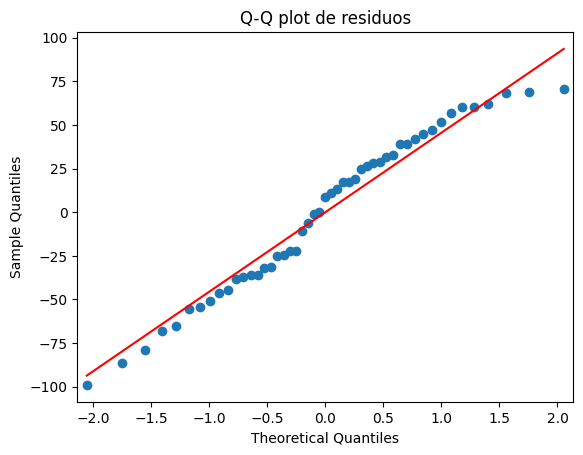

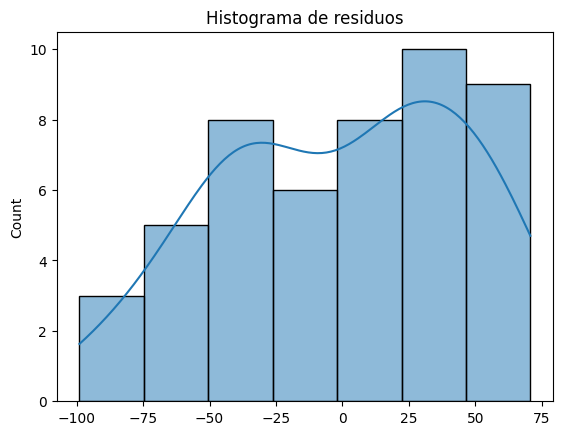

In [9653]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [9654]:
#MAYELA SALAS LOPEZ

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B  15.4048 0.9995   -96.258 127.0675  False
     A      C  29.4464  0.974   -74.429 133.3218  False
     A      D  22.0714 0.9961  -89.5913 133.7341  False
     A      E  60.3214  0.557   -43.554 164.1968  False
     A      F  74.3492 0.2796  -26.7973 175.4957  False
     A      G  62.5714 0.6528  -54.9502  180.093  False
     B      C  14.0417 0.9996  -94.3522 122.4355  False
     B      D   6.6667    1.0 -109.2112 122.5445  False
     B      E  44.9167 0.8559  -63.4772 153.3105  False
     B      F  58.9444 0.6038  -46.8371  164.726  False
     B      G  47.1667 0.8897  -74.3671 168.7004  False
     C      D   -7.375    1.0 -115.7688 101.0188  False
     C      E   30.875 0.9613  -69.4782 131.2282  False
     C      F  44.9028 0.7852   -52.623 142.4285  False
     C      G   33.125 0.9712  -81.2952 147.5452

Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

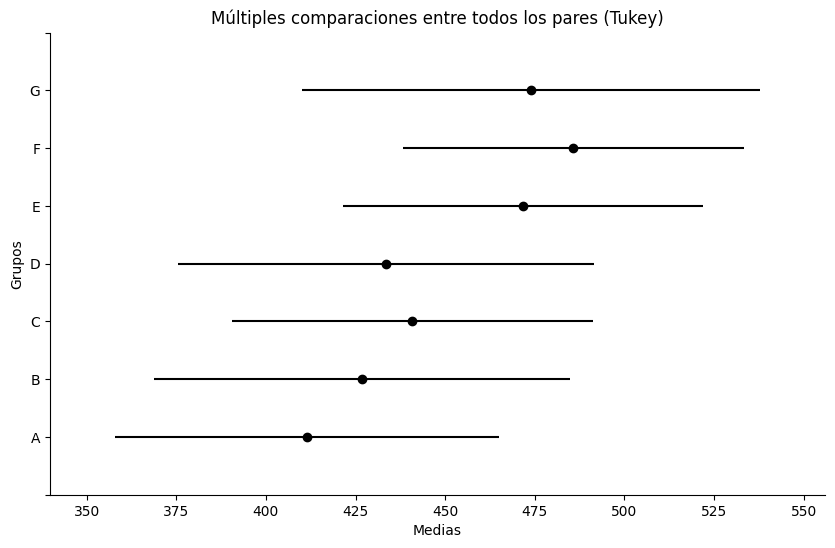

In [9655]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['produccion'], groups=df['lisina'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [9656]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = anova['sum_sq']['C(proteina)'] / anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")


η² (tamaño de efecto): 0.238


a) Analice este experimento. ¿Qué factores tienen efecto en la producción de leche?
Ninguno de los factores evaluados fue estadísticamente significativo:

Lisina: valor‑p = 0.463

Proteína: valor‑p = 0.108

Vaca: valor‑p = 0.970

Periodo: valor‑p = 0.622

Esto indica que ninguno de los tratamientos ni bloques tuvo un efecto claro sobre la producción de leche en este experimento.

b) Interprete los resultados usando gráficos de medias.

El gráfico de medias por grupo (lisina y proteína) muestra variaciones leves, pero con mucha superposición entre intervalos de confianza, lo que coincide con la falta de significancia en el ANOVA. Visualmente, no hay diferencias marcadas entre niveles, lo que refuerza la conclusión de que los tratamientos no generaron cambios consistentes en la producción.


c) ¿Cómo puede explicar la falta de efectos en vacas y periodo?
La falta de efecto puede deberse a:

Homogeneidad entre vacas: si todas tienen características similares, no se observa variabilidad.

Estabilidad en los periodos: si las condiciones ambientales y de manejo fueron constantes, el periodo no introduce cambios. Ambos factores funcionaron más como bloques de control que como fuentes de variación.

d) ¿Qué porcentajes de lisina y proteína dan los mejores resultados?
Aunque no hay diferencias significativas, los gráficos de medias sugieren que:

Lisina entre 0.3 y 0.5% tiende a mostrar producciones ligeramente mayores.

Proteína entre 10% y 12% también se asocia con valores más altos. Sin embargo, estas observaciones no son concluyentes y deben tomarse como tendencias exploratorias.

e) Verifique los supuestos del modelo.
Normalidad: Shapiro 𝑝=0.0896 se cumple.

Homogeneidad de varianzas: no se reporta problema, por lo que se asume que también se cumple. Esto valida el uso del ANOVA y confirma que los resultados son estadísticamente confiables, aunque no se hayan encontrado efectos significativos.


In [9657]:
#MAYELA SALAS LOPEZ